# 60 — Synthetic Deployment Robustness Simulation

**Project:** AI VPN Firewall — Thesis  
**Source pipeline:** Clean Pipeline (NB41-55)  
**Goal:** Evaluate classifier robustness under realistic network perturbations.

---

## Rationale

Deploying a VPN detection model in production exposes it to conditions that differ
from training: variable latency, packet truncation, flow length variation,
direction-labelling errors, and burst reshaping. This notebook applies five
synthetic perturbation types at graded strengths to the test set and measures:

| Perturbation | What it simulates |
|---|---|
| **Latency inflation** | VPN tunnel overhead, congested links |
| **Packet truncation** | Early classification (first N packets) |
| **Flow-length scaling** | Shorter / longer sessions |
| **Direction inversion** | Mis-labelled packet direction |
| **Burst reshaping** | Different application behaviour / MTU changes |

**Interpretation target:** demonstrate threshold instability under structural perturbations.

## 0. Setup

In [1]:
import sys, gc, warnings, time, json
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FEATURES_PATH = ROOT / "artifacts" / "clean_pipeline" / "features.parquet"
OUT = ROOT / "artifacts" / "conference_eval"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

N_EST = 200
SEED  = 42

print(f"Root: {ROOT}")

Root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


---
## Step 1 — Feature Set & Perturbation Definitions

In [2]:
from src.clean_pipeline.feature_families import get_family

FEAT_COLS = list(get_family("safe_core_plus_temporal"))  # 21 direction-invariant
print(f"Feature set: safe_core_plus_temporal ({len(FEAT_COLS)} features)")
print(f"  {FEAT_COLS}")

# Direction-augmented extras for the direction-inversion test
DIR_EXTRA = [
    "fwd_packets", "bwd_packets", "fwd_bytes", "bwd_bytes",
    "fwd_mean_pkt_len", "bwd_mean_pkt_len", "packet_ratio", "byte_ratio",
]

# Semantic groups for targeted perturbation
IAT_SCALE_FEATS  = ["iat_mean", "iat_std", "iat_median", "iat_p25", "iat_p75", "iat_iqr"]
DURATION_FEATS   = ["flow_duration"]
RATE_FEATS       = ["packet_rate", "byte_rate"]
COUNT_FEATS      = ["total_packets", "total_bytes"]
SIZE_STAT_FEATS  = [
    "mean_pkt_len", "std_pkt_len", "median_pkt_len",
    "p25_pkt_len", "p75_pkt_len", "max_pkt_len", "min_pkt_len",
    "pkt_len_cv", "pkt_len_iqr",
]
print("\n\u2713 Perturbation target groups defined.")

Feature set: safe_core_plus_temporal (21 features)
  ['total_packets', 'total_bytes', 'mean_pkt_len', 'std_pkt_len', 'median_pkt_len', 'p25_pkt_len', 'p75_pkt_len', 'iat_mean', 'iat_std', 'iat_median', 'flow_duration', 'packet_rate', 'byte_rate', 'max_pkt_len', 'min_pkt_len', 'iat_cv', 'iat_p25', 'iat_p75', 'iat_iqr', 'pkt_len_cv', 'pkt_len_iqr']

✓ Perturbation target groups defined.


---
## Step 2 — Load Data, Split & Train Baseline Model

In [3]:
# ── Helpers ─────────────────────────────────────────────────────

def safe_auc(y, s):
    if len(np.unique(y)) < 2 or len(y) < 5:
        return float("nan")
    return float(roc_auc_score(y, s))

def best_f1_thr(y, s):
    if len(np.unique(y)) < 2:
        return 0.5
    pr, re, th = precision_recall_curve(y, s)
    f1 = 2 * pr * re / (pr + re + 1e-12)
    return float(th[min(np.argmax(f1), len(th) - 1)])

def do_split(df, seed=42, train_r=0.70, val_r=0.15):
    rng = np.random.default_rng(seed)
    cap = df.groupby(["dataset", "label", "capture_id"]).agg(
        n=("flow_id", "count")
    ).reset_index()
    assigns = {}
    for (ds, lbl), grp in cap.groupby(["dataset", "label"]):
        nc = len(grp)
        if nc < 3:
            for c in grp["capture_id"]:
                assigns[str(c)] = "train"
            continue
        idx = rng.permutation(nc)
        cids = grp["capture_id"].values[idx]
        flows = grp["n"].values[idx]
        min_p = 1 if nc < 6 else 2
        order = np.argsort(flows)
        test_ids = [str(cids[order[i]]) for i in range(min_p)]
        val_ids  = [str(cids[order[i]]) for i in range(min_p, 2 * min_p)]
        rest     = [str(cids[order[i]]) for i in range(2 * min_p, nc)]
        for c in test_ids: assigns[c] = "test"
        for c in val_ids:  assigns[c] = "val"
        total = int(flows.sum())
        tgt = {
            "train": int(total * train_r),
            "val":   int(total * val_r),
            "test":  total - int(total * train_r) - int(total * val_r),
        }
        cur = {"train": 0, "val": 0, "test": 0}
        for c in test_ids:
            cur["test"] += int(cap[cap.capture_id == c]["n"].iloc[0])
        for c in val_ids:
            cur["val"]  += int(cap[cap.capture_id == c]["n"].iloc[0])
        for c in rest:
            w = int(cap[cap.capture_id == c]["n"].iloc[0])
            best = min(
                ("train", "val", "test"),
                key=lambda s: sum(abs((cur[k] + (w if k == s else 0)) - tgt[k]) for k in tgt),
            )
            assigns[c] = best
            cur[best] += w
    out = df.copy()
    out["split"] = out["capture_id"].astype(str).map(assigns).fillna("train")
    return out

def train_ensemble(X_tr, y_tr, X_val, y_val, n_est=200):
    models = {}
    try:
        import xgboost as xgb
        m = xgb.XGBClassifier(
            n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=max(1.0, (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)),
            eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0,
        )
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        models["xgb"] = m
    except Exception: pass
    try:
        import lightgbm as lgb
        m = lgb.LGBMClassifier(
            n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, is_unbalance=True,
            random_state=42, n_jobs=-1, verbose=-1,
        )
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(0)])
        models["lgb"] = m
    except Exception: pass
    try:
        from catboost import CatBoostClassifier
        m = CatBoostClassifier(
            iterations=n_est, depth=5, learning_rate=0.05,
            auto_class_weights="Balanced", random_seed=42, verbose=0,
        )
        m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
        models["cb"] = m
    except Exception: pass
    return models

def ens_predict(models, X):
    return np.mean([m.predict_proba(X)[:, 1] for m in models.values()], axis=0)

print("\u2713 Helpers defined.")

✓ Helpers defined.


In [4]:
# ── Load & split ───────────────────────────────────────────────
df_all = pd.read_parquet(FEATURES_PATH)
DATASETS = sorted(df_all["dataset"].unique())
print(f"Loaded {len(df_all):,} flows, datasets: {DATASETS}")
for ds in DATASETS:
    sub = df_all[df_all.dataset == ds]
    print(f"  {ds}: {len(sub):,} flows (VPN={int(sub.label.sum()):,})")

# Check which directional columns are available
dir_available = [c for c in DIR_EXTRA if c in df_all.columns]
use_dir = len(dir_available) == len(DIR_EXTRA)
FEAT_COLS_FULL = FEAT_COLS + DIR_EXTRA if use_dir else FEAT_COLS
print(f"\nUsing {len(FEAT_COLS_FULL)} features (direction-augmented={use_dir})")

missing = [f for f in FEAT_COLS_FULL if f not in df_all.columns]
assert not missing, f"Missing features: {missing}"


Loaded 72,612 flows, datasets: ['iscx', 'usbvpn', 'vnat']
  iscx: 11,801 flows (VPN=2,943)
  usbvpn: 52,704 flows (VPN=8,456)
  vnat: 8,107 flows (VPN=374)

Using 21 features (direction-augmented=False)


In [5]:
# ── Train baseline model ───────────────────────────────────────
t0 = time.time()
df_split = do_split(df_all, seed=SEED)

tr = df_split[df_split.split == "train"]
va = df_split[df_split.split == "val"]
te = df_split[df_split.split == "test"]

X_tr = tr[FEAT_COLS_FULL].values.astype(np.float32)
y_tr = tr["label"].values
X_va = va[FEAT_COLS_FULL].values.astype(np.float32)
y_va = va["label"].values
X_te = te[FEAT_COLS_FULL].values.astype(np.float32)
y_te = te["label"].values
ds_te = te["dataset"].values

print(f"Train {len(y_tr):,}  Val {len(y_va):,}  Test {len(y_te):,}")

models = train_ensemble(X_tr, y_tr, X_va, y_va, N_EST)
print(f"Ensemble models: {list(models.keys())}")

# Baseline predictions & threshold
base_probs = ens_predict(models, X_te)
threshold = best_f1_thr(y_va, ens_predict(models, X_va))
base_preds = (base_probs >= threshold).astype(int)
base_auc = safe_auc(y_te, base_probs)
print(f"\nBaseline test AUC = {base_auc:.4f}")
print(f"Decision threshold = {threshold:.4f}")
print(f"Training elapsed:   {time.time() - t0:.1f}s")

Train 62,461  Val 4,948  Test 5,203
Ensemble models: ['xgb', 'lgb', 'cb']

Baseline test AUC = 0.9982
Decision threshold = 0.5276
Training elapsed:   25.8s


---
## Step 3 — Define & Apply Perturbations

Each perturbation modifies the feature matrix directly, simulating what the
feature extractor would produce under altered network conditions.

In [6]:
def _col_idx(feat_cols, names):
    return [feat_cols.index(n) for n in names if n in feat_cols]

def perturb_latency(X, feat_cols, factor):
    Xp = X.copy()
    for i in _col_idx(feat_cols, IAT_SCALE_FEATS + DURATION_FEATS):
        Xp[:, i] *= factor
    for i in _col_idx(feat_cols, RATE_FEATS):
        Xp[:, i] /= factor
    return Xp

def perturb_truncation(X, feat_cols, keep_pct, rng):
    frac = keep_pct / 100.0
    Xp = X.copy()
    for i in _col_idx(feat_cols, COUNT_FEATS):
        Xp[:, i] *= frac
    for i in _col_idx(feat_cols, DURATION_FEATS):
        Xp[:, i] *= frac
    noise_scale = 0.03 * (1.0 - frac)
    for i in _col_idx(feat_cols, SIZE_STAT_FEATS):
        col = Xp[:, i]
        noise = rng.normal(0, noise_scale, size=len(col)) * np.abs(col)
        Xp[:, i] = np.maximum(col + noise, 0.0)
    return Xp

def perturb_flow_length(X, feat_cols, scale):
    Xp = X.copy()
    for i in _col_idx(feat_cols, COUNT_FEATS):
        Xp[:, i] *= scale
    for i in _col_idx(feat_cols, DURATION_FEATS):
        Xp[:, i] *= scale
    return Xp

def perturb_direction_inversion(X, feat_cols):
    Xp = X.copy()
    swap_pairs = [
        ("fwd_packets", "bwd_packets"),
        ("fwd_bytes", "bwd_bytes"),
        ("fwd_mean_pkt_len", "bwd_mean_pkt_len"),
    ]
    for a, b in swap_pairs:
        if a in feat_cols and b in feat_cols:
            ia, ib = feat_cols.index(a), feat_cols.index(b)
            Xp[:, ia], Xp[:, ib] = X[:, ib].copy(), X[:, ia].copy()
    if "packet_ratio" in feat_cols:
        idx = feat_cols.index("packet_ratio")
        Xp[:, idx] = np.where(Xp[:, idx] > 0, 1.0 / np.maximum(Xp[:, idx], 1e-9), 0.0)
    if "byte_ratio" in feat_cols:
        idx = feat_cols.index("byte_ratio")
        Xp[:, idx] = np.where(Xp[:, idx] > 0, 1.0 / np.maximum(Xp[:, idx], 1e-9), 0.0)
    return Xp

def perturb_burst_reshape(X, feat_cols, noise_std, rng):
    Xp = X.copy()
    for i in _col_idx(feat_cols, SIZE_STAT_FEATS):
        col = Xp[:, i]
        noise = rng.normal(0, noise_std, size=len(col)) * np.abs(col)
        Xp[:, i] = np.maximum(col + noise, 0.0)
    return Xp

print("\u2713 Perturbation functions defined.")

✓ Perturbation functions defined.


In [7]:
# ── Build perturbation schedule ────────────────────────────────
rng = np.random.default_rng(SEED)
PERTURBATIONS = []

for factor in [1.2, 1.5, 2.0]:
    PERTURBATIONS.append({
        "type": "latency_inflation",
        "label": f"latency \u00d7{factor}",
        "strength": factor,
        "fn": lambda X, f=factor: perturb_latency(X, FEAT_COLS_FULL, f),
    })

for keep in [50, 75]:
    PERTURBATIONS.append({
        "type": "packet_truncation",
        "label": f"trunc {keep}%",
        "strength": 1.0 - keep / 100.0,
        "fn": lambda X, k=keep: perturb_truncation(
            X, FEAT_COLS_FULL, k, np.random.default_rng(SEED)),
    })

for scale in [0.8, 1.2]:
    PERTURBATIONS.append({
        "type": "flow_length_scaling",
        "label": f"length \u00d7{scale}",
        "strength": abs(scale - 1.0),
        "fn": lambda X, s=scale: perturb_flow_length(X, FEAT_COLS_FULL, s),
    })

PERTURBATIONS.append({
    "type": "direction_inversion",
    "label": "dir inversion",
    "strength": 1.0,
    "fn": lambda X: perturb_direction_inversion(X, FEAT_COLS_FULL),
})

for ns in [0.05, 0.10, 0.15]:
    PERTURBATIONS.append({
        "type": "burst_reshaping",
        "label": f"burst \u03c3={ns}",
        "strength": ns,
        "fn": lambda X, s=ns: perturb_burst_reshape(
            X, FEAT_COLS_FULL, s, np.random.default_rng(SEED)),
    })

print(f"Perturbation schedule: {len(PERTURBATIONS)} configurations")
for p in PERTURBATIONS:
    print(f"  {p['type']:25s} | {p['label']}")

Perturbation schedule: 11 configurations
  latency_inflation         | latency ×1.2
  latency_inflation         | latency ×1.5
  latency_inflation         | latency ×2.0
  packet_truncation         | trunc 50%
  packet_truncation         | trunc 75%
  flow_length_scaling       | length ×0.8
  flow_length_scaling       | length ×1.2
  direction_inversion       | dir inversion
  burst_reshaping           | burst σ=0.05
  burst_reshaping           | burst σ=0.1
  burst_reshaping           | burst σ=0.15


---
## Step 4 — Run Perturbations & Collect Metrics

In [8]:
result_rows = []
benign_mask = y_te == 0
vpn_mask    = y_te == 1
n_benign    = int(benign_mask.sum())

for p in PERTURBATIONS:
    X_pert = p["fn"](X_te).astype(np.float32)
    pert_probs = ens_predict(models, X_pert)
    pert_preds = (pert_probs >= threshold).astype(int)

    prob_drift = np.abs(pert_probs - base_probs)
    mean_drift   = float(np.mean(prob_drift))
    max_drift    = float(np.max(prob_drift))
    median_drift = float(np.median(prob_drift))

    crossings     = (pert_preds != base_preds)
    crossing_rate = float(crossings.mean())

    new_fp  = int(((base_preds == 0) & (pert_preds == 1) & benign_mask).sum())
    lost_tp = int(((base_preds == 1) & (pert_preds == 0) & vpn_mask).sum())

    base_fp  = int((base_preds[benign_mask] == 1).sum())
    pert_fp  = int((pert_preds[benign_mask] == 1).sum())
    base_fpr = base_fp / max(n_benign, 1)
    pert_fpr = pert_fp / max(n_benign, 1)
    fp_inflation = pert_fpr - base_fpr

    pert_auc = safe_auc(y_te, pert_probs)

    row = {
        "perturbation_type": p["type"],
        "perturbation_label": p["label"],
        "perturbation_strength": p["strength"],
        "mean_prob_drift": mean_drift,
        "median_prob_drift": median_drift,
        "max_prob_drift": max_drift,
        "threshold_crossing_rate": crossing_rate,
        "new_false_positives": new_fp,
        "lost_true_positives": lost_tp,
        "base_fpr": base_fpr,
        "pert_fpr": pert_fpr,
        "fp_inflation": fp_inflation,
        "base_auc": base_auc,
        "pert_auc": pert_auc,
        "auc_delta": pert_auc - base_auc,
        "n_test": len(y_te),
        "n_benign": n_benign,
        "threshold": threshold,
    }

    for ds in DATASETS:
        ds_mask = ds_te == ds
        if ds_mask.sum() == 0:
            continue
        row[f"{ds}_mean_drift"]    = float(np.mean(np.abs(pert_probs[ds_mask] - base_probs[ds_mask])))
        row[f"{ds}_crossing_rate"] = float((pert_preds[ds_mask] != base_preds[ds_mask]).mean())
        ds_ben = (y_te[ds_mask] == 0)
        row[f"{ds}_base_fp"]  = int((base_preds[ds_mask][ds_ben] == 1).sum())
        row[f"{ds}_pert_fp"]  = int((pert_preds[ds_mask][ds_ben] == 1).sum())
        row[f"{ds}_n_benign"] = int(ds_ben.sum())

    result_rows.append(row)
    print(f"  {p['label']:20s} | drift={mean_drift:.4f} "
          f"| cross={crossing_rate:.4f} | FP \u0394={fp_inflation:+.4f} "
          f"| AUC {pert_auc:.4f} (\u0394{pert_auc - base_auc:+.4f})")

results_df = pd.DataFrame(result_rows)

baseline_row = {
    "perturbation_type": "none", "perturbation_label": "baseline",
    "perturbation_strength": 0.0,
    "mean_prob_drift": 0.0, "median_prob_drift": 0.0, "max_prob_drift": 0.0,
    "threshold_crossing_rate": 0.0, "new_false_positives": 0, "lost_true_positives": 0,
    "base_fpr": base_fpr, "pert_fpr": base_fpr, "fp_inflation": 0.0,
    "base_auc": base_auc, "pert_auc": base_auc, "auc_delta": 0.0,
    "n_test": len(y_te), "n_benign": n_benign, "threshold": threshold,
}
results_df = pd.concat([pd.DataFrame([baseline_row]), results_df], ignore_index=True)

print(f"\n\u2713 {len(results_df)} result rows (including baseline)")
display(results_df[
    ["perturbation_label", "mean_prob_drift", "threshold_crossing_rate",
     "fp_inflation", "pert_auc", "auc_delta"]
].round(4).style.set_caption("Perturbation Impact Summary"))

  latency ×1.2         | drift=0.0194 | cross=0.0038 | FP Δ=+0.0038 | AUC 0.9980 (Δ-0.0001)
  latency ×1.5         | drift=0.0381 | cross=0.0133 | FP Δ=+0.0172 | AUC 0.9971 (Δ-0.0011)
  latency ×2.0         | drift=0.0608 | cross=0.0294 | FP Δ=+0.0404 | AUC 0.9948 (Δ-0.0034)
  trunc 50%            | drift=0.1231 | cross=0.0940 | FP Δ=+0.0286 | AUC 0.9645 (Δ-0.0336)
  trunc 75%            | drift=0.0871 | cross=0.0352 | FP Δ=+0.0277 | AUC 0.9821 (Δ-0.0160)
  length ×0.8          | drift=0.0453 | cross=0.0048 | FP Δ=-0.0016 | AUC 0.9965 (Δ-0.0017)
  length ×1.2          | drift=0.0114 | cross=0.0042 | FP Δ=-0.0013 | AUC 0.9977 (Δ-0.0005)
  dir inversion        | drift=0.0000 | cross=0.0000 | FP Δ=+0.0000 | AUC 0.9982 (Δ+0.0000)
  burst σ=0.05         | drift=0.1034 | cross=0.0757 | FP Δ=+0.0563 | AUC 0.9525 (Δ-0.0457)
  burst σ=0.1          | drift=0.1332 | cross=0.0955 | FP Δ=+0.0633 | AUC 0.9400 (Δ-0.0581)
  burst σ=0.15         | drift=0.1597 | cross=0.1224 | FP Δ=+0.0796 | AUC 0.9236

,perturbation_label,mean_prob_drift,threshold_crossing_rate,fp_inflation,pert_auc,auc_delta
0,baseline,0.000000,0.000000,0.000000,0.998200,0.000000
1,latency ×1.2,0.019400,0.003800,0.003800,0.998000,-0.000100
2,latency ×1.5,0.038100,0.013300,0.017200,0.997100,-0.001100
3,latency ×2.0,0.060800,0.029400,0.040400,0.994800,-0.003400
4,trunc 50%,0.123100,0.094000,0.028600,0.964500,-0.033600
5,trunc 75%,0.087100,0.035200,0.027700,0.982100,-0.016000
6,length ×0.8,0.045300,0.004800,-0.001600,0.996500,-0.001700
7,length ×1.2,0.011400,0.004200,-0.001300,0.997700,-0.000500
8,dir inversion,0.000000,0.000000,0.000000,0.998200,0.000000
9,burst σ=0.05,0.103400,0.075700,0.056300,0.952500,-0.045700


---
## Step 5 — Plots

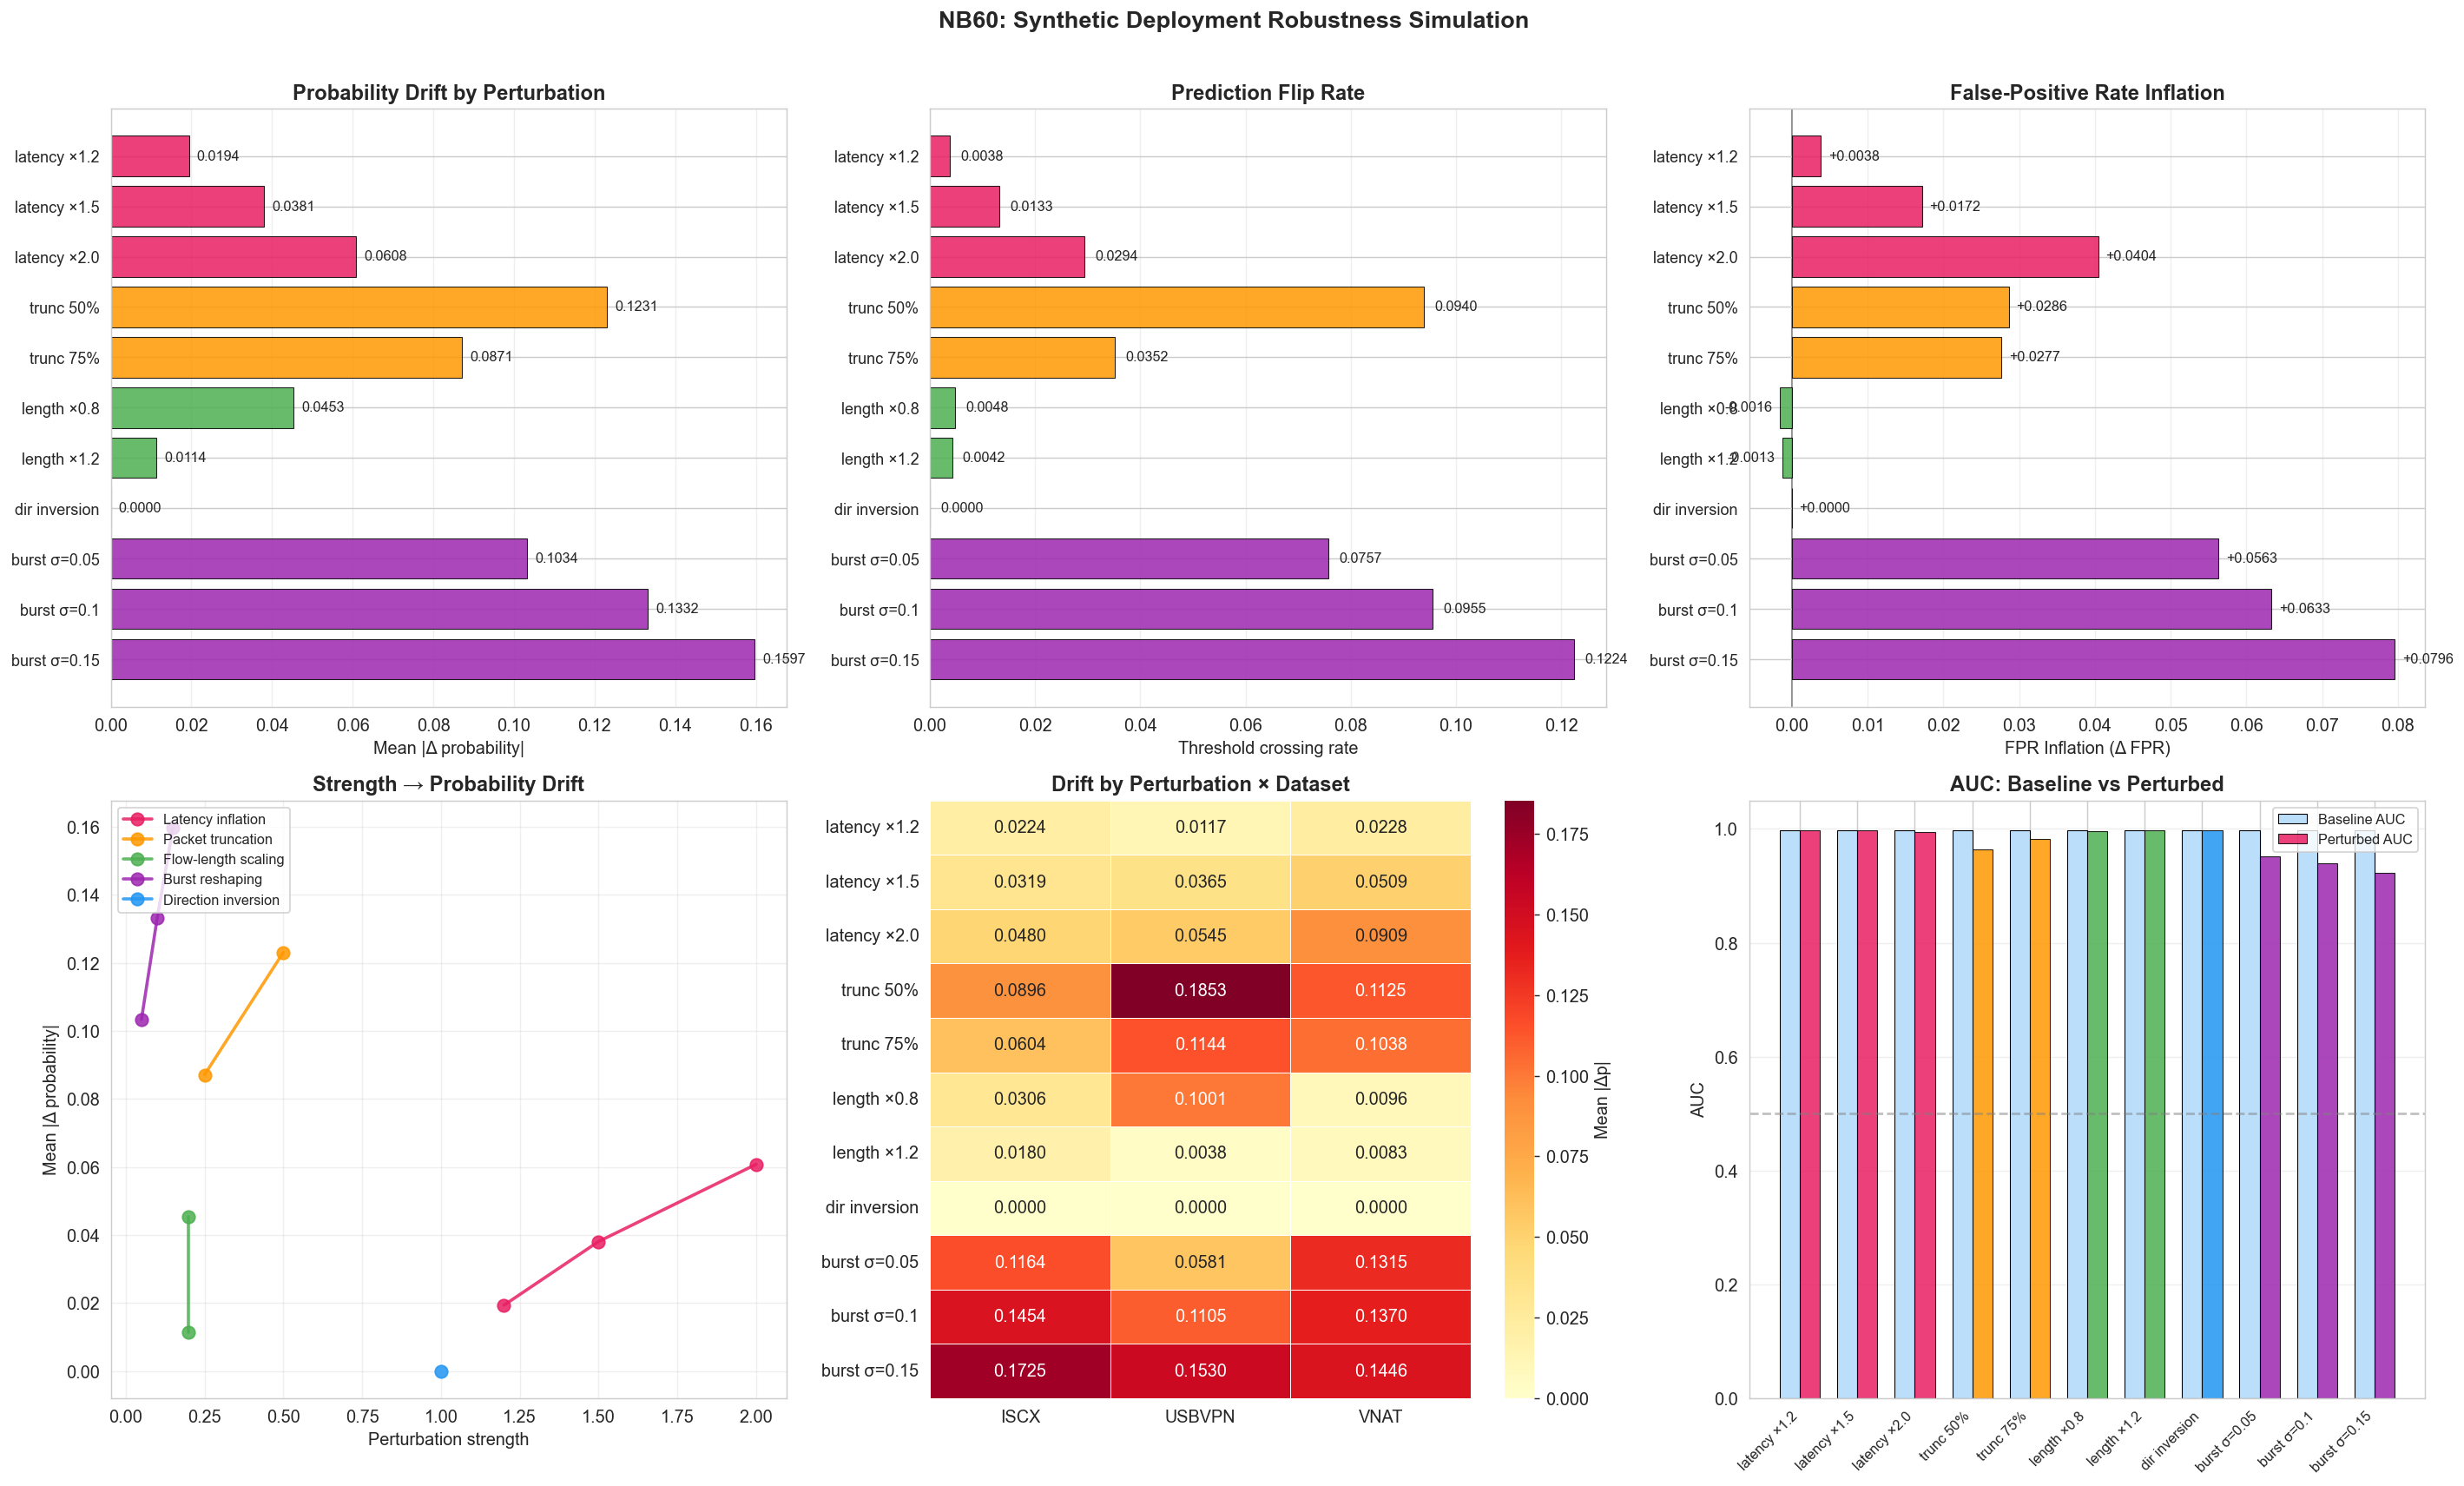

[OK] Saved: deployment_robustness_curves.png


In [9]:
TYPE_COLORS = {
    "none": "#9E9E9E",
    "latency_inflation": "#E91E63",
    "packet_truncation": "#FF9800",
    "flow_length_scaling": "#4CAF50",
    "direction_inversion": "#2196F3",
    "burst_reshaping": "#9C27B0",
}
TYPE_LABELS = {
    "none": "Baseline",
    "latency_inflation": "Latency inflation",
    "packet_truncation": "Packet truncation",
    "flow_length_scaling": "Flow-length scaling",
    "direction_inversion": "Direction inversion",
    "burst_reshaping": "Burst reshaping",
}

plot_df = results_df[results_df.perturbation_type != "none"].copy()
colors  = [TYPE_COLORS[t] for t in plot_df["perturbation_type"]]

fig, axes = plt.subplots(2, 3, figsize=(22, 13))

# (0,0) Probability drift
ax = axes[0, 0]
ax.barh(range(len(plot_df)), plot_df["mean_prob_drift"],
        color=colors, edgecolor="black", linewidth=0.6, alpha=0.85)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["perturbation_label"], fontsize=10)
ax.set_xlabel("Mean |\u0394 probability|")
ax.set_title("Probability Drift by Perturbation", fontweight="bold")
ax.invert_yaxis()
for i, v in enumerate(plot_df["mean_prob_drift"]):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)

# (0,1) Threshold crossing rate
ax = axes[0, 1]
ax.barh(range(len(plot_df)), plot_df["threshold_crossing_rate"],
        color=colors, edgecolor="black", linewidth=0.6, alpha=0.85)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["perturbation_label"], fontsize=10)
ax.set_xlabel("Threshold crossing rate")
ax.set_title("Prediction Flip Rate", fontweight="bold")
ax.invert_yaxis()
for i, v in enumerate(plot_df["threshold_crossing_rate"]):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)

# (0,2) FP inflation
ax = axes[0, 2]
ax.barh(range(len(plot_df)), plot_df["fp_inflation"],
        color=colors, edgecolor="black", linewidth=0.6, alpha=0.85)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["perturbation_label"], fontsize=10)
ax.set_xlabel("FPR Inflation (\u0394 FPR)")
ax.set_title("False-Positive Rate Inflation", fontweight="bold")
ax.invert_yaxis()
ax.axvline(0, color="gray", linewidth=1, zorder=0)
for i, v in enumerate(plot_df["fp_inflation"]):
    ax.text(v + 0.001 if v >= 0 else v - 0.001, i,
            f"{v:+.4f}", va="center", fontsize=9,
            ha="left" if v >= 0 else "right")
ax.grid(axis="x", alpha=0.3)

# (1,0) Strength vs drift
ax = axes[1, 0]
for ptype in ["latency_inflation", "packet_truncation", "flow_length_scaling",
              "burst_reshaping", "direction_inversion"]:
    sub = results_df[results_df.perturbation_type == ptype]
    if len(sub) == 0:
        continue
    ax.plot(sub["perturbation_strength"], sub["mean_prob_drift"],
            "o-", color=TYPE_COLORS[ptype], label=TYPE_LABELS[ptype],
            markersize=8, linewidth=2, alpha=0.85)
ax.set_xlabel("Perturbation strength")
ax.set_ylabel("Mean |\u0394 probability|")
ax.set_title("Strength \u2192 Probability Drift", fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

# (1,1) Per-dataset heatmap
ax = axes[1, 1]
heat_data = []
for _, row in plot_df.iterrows():
    hrow = {"perturbation": row["perturbation_label"]}
    for ds in DATASETS:
        hrow[ds.upper()] = row.get(f"{ds}_mean_drift", 0.0)
    heat_data.append(hrow)
heat_df = pd.DataFrame(heat_data).set_index("perturbation")
sns.heatmap(heat_df, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Mean |\u0394p|"})
ax.set_title("Drift by Perturbation \u00d7 Dataset", fontweight="bold")
ax.set_ylabel("")

# (1,2) AUC comparison
ax = axes[1, 2]
x_pos = np.arange(len(plot_df))
width = 0.35
ax.bar(x_pos - width / 2, plot_df["base_auc"], width,
       color="#BBDEFB", edgecolor="black", linewidth=0.6, label="Baseline AUC")
pert_colors = [TYPE_COLORS[t] for t in plot_df["perturbation_type"]]
ax.bar(x_pos + width / 2, plot_df["pert_auc"], width,
       color=pert_colors, edgecolor="black", linewidth=0.6, label="Perturbed AUC",
       alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["perturbation_label"], fontsize=9, rotation=45, ha="right")
ax.set_ylabel("AUC")
ax.set_title("AUC: Baseline vs Perturbed", fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("NB60: Synthetic Deployment Robustness Simulation",
             fontsize=15, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "deployment_robustness_curves.png"), dpi=150, bbox_inches="tight")
plt.savefig(str(OUT / "deployment_robustness_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: deployment_robustness_curves.png")

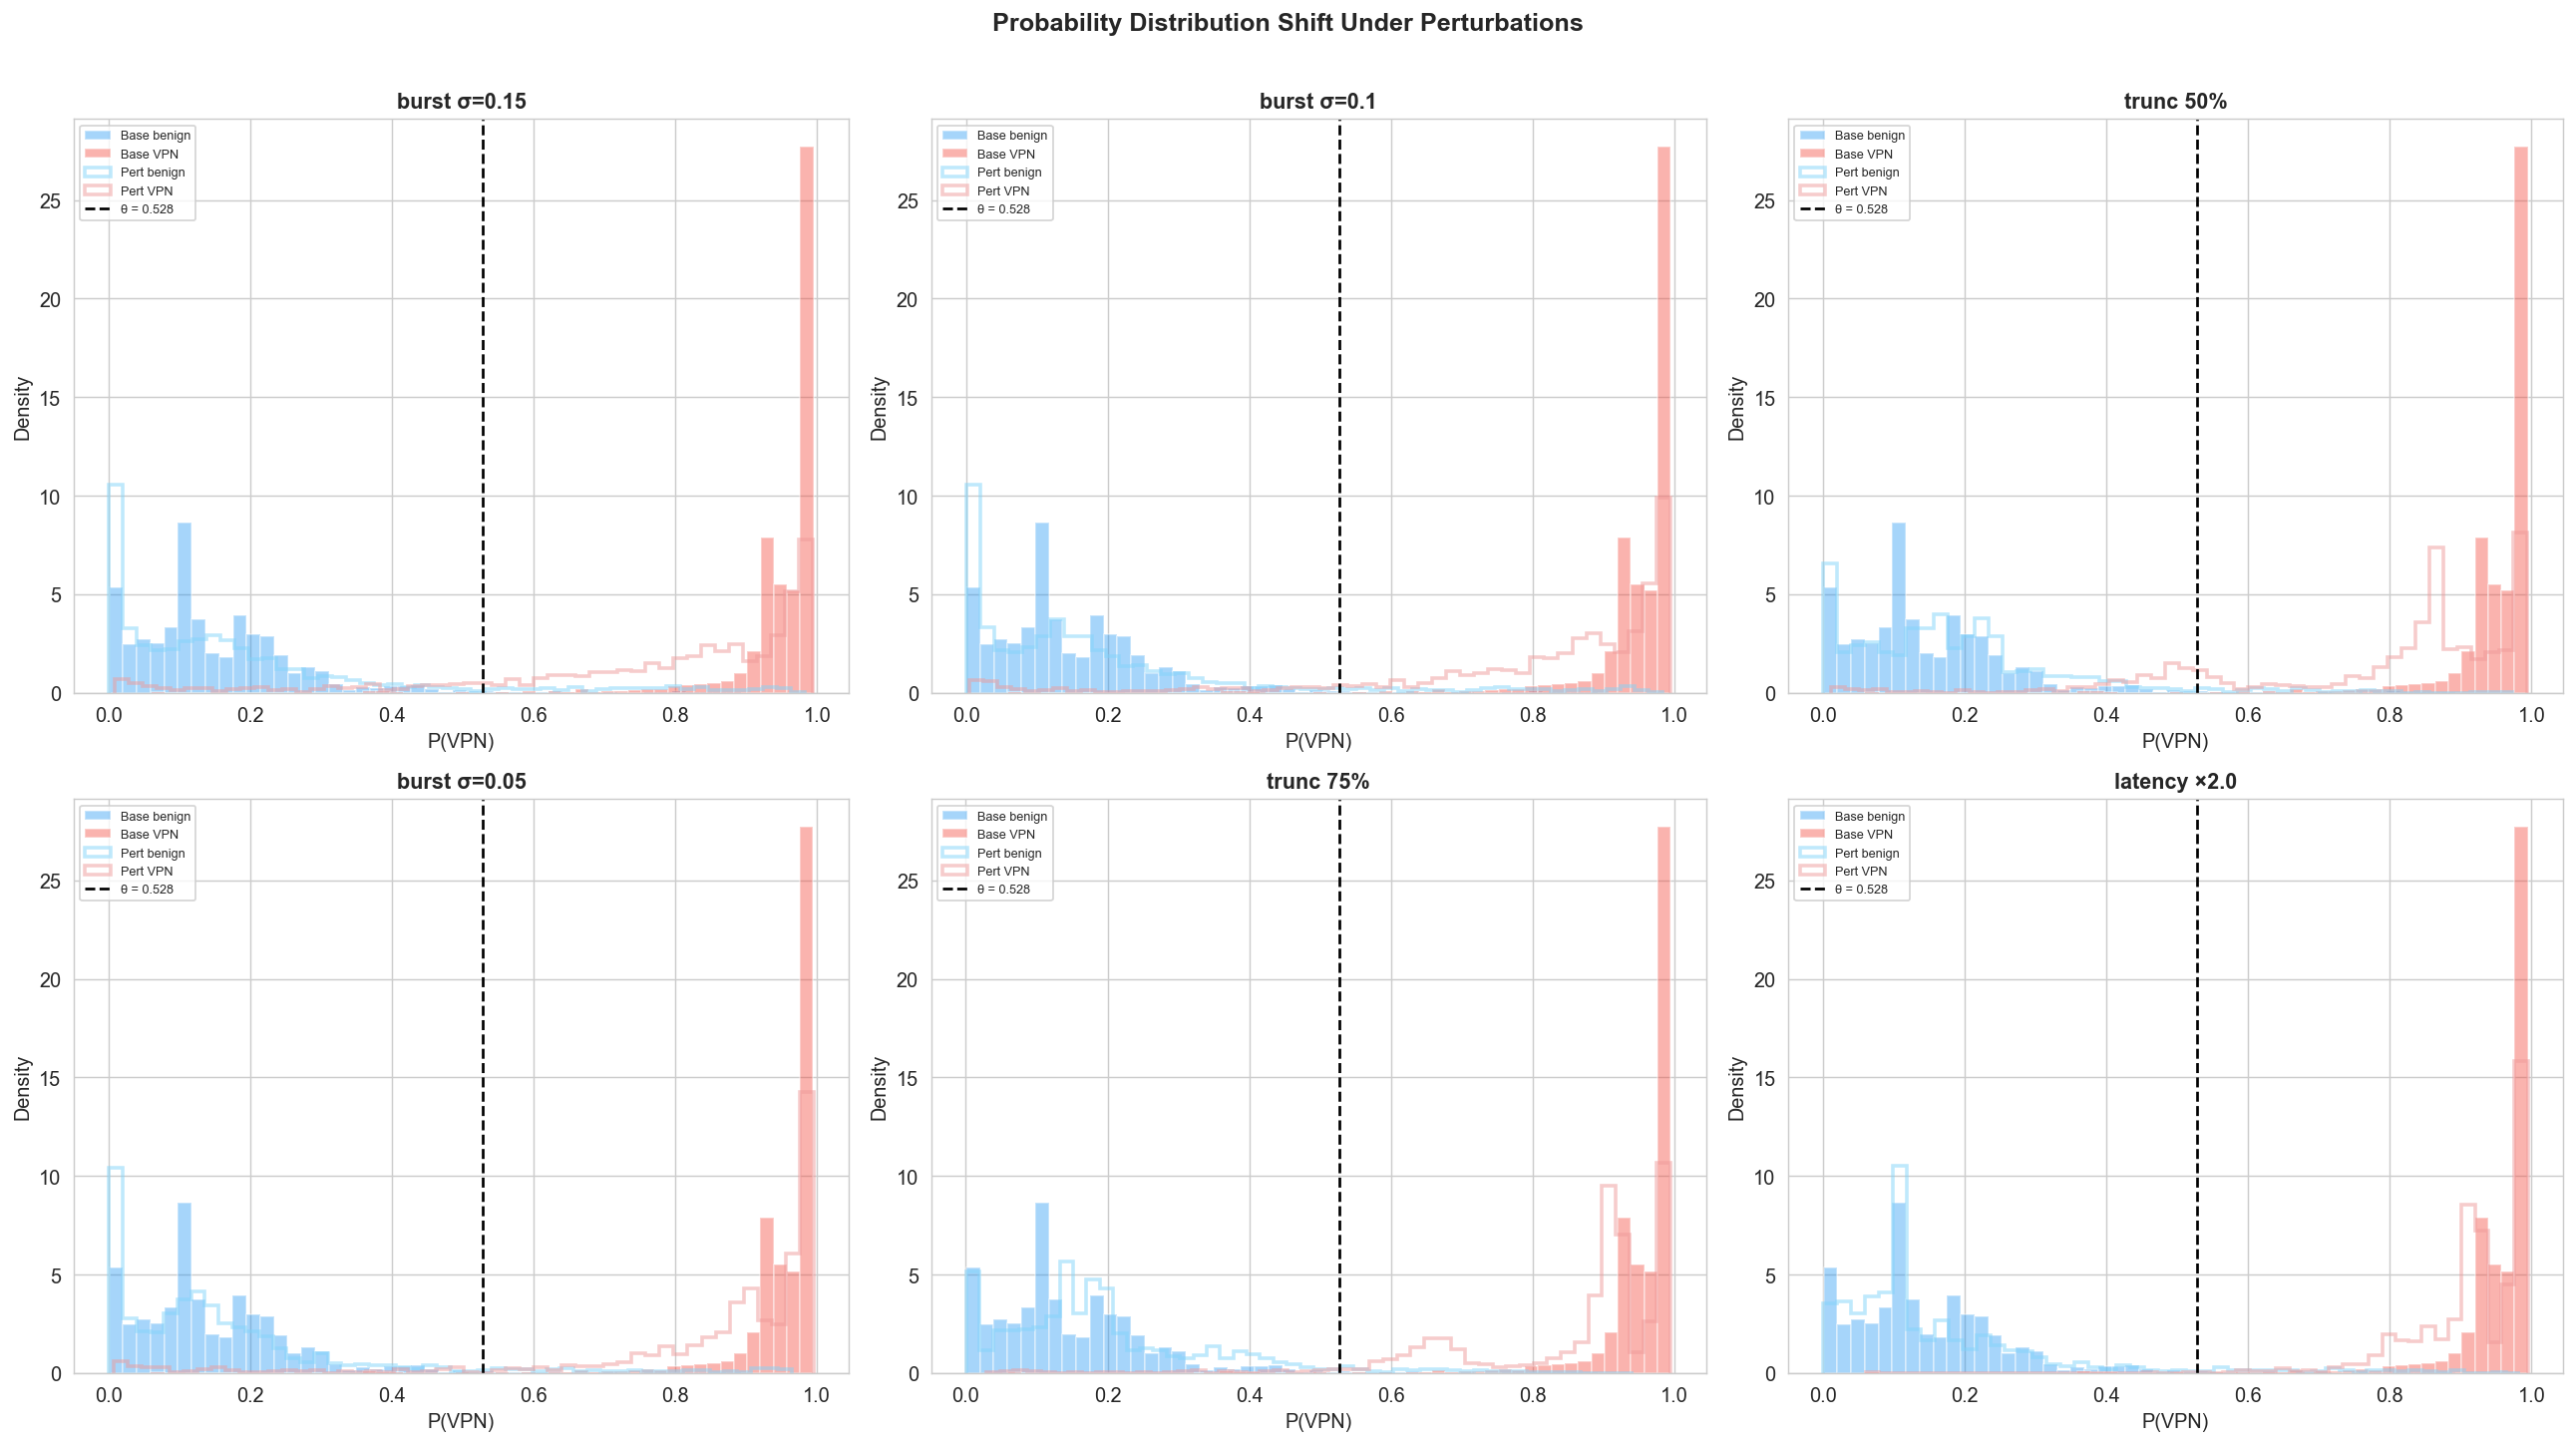

[OK] Saved: deployment_robustness_distributions.png


In [10]:
# ── Supplementary: probability distribution shift ──────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(20, 11))
axes_flat = axes2.flatten()

top_perts = plot_df.nlargest(min(6, len(plot_df)), "mean_prob_drift")

for ax_i, (_, prow) in enumerate(top_perts.iterrows()):
    ax = axes_flat[ax_i]
    matching = [p for p in PERTURBATIONS if p["label"] == prow["perturbation_label"]]
    if not matching:
        continue
    X_pert = matching[0]["fn"](X_te).astype(np.float32)
    pert_probs_i = ens_predict(models, X_pert)

    ax.hist(base_probs[y_te == 0], bins=50, alpha=0.4, color="#2196F3",
            label="Base benign", density=True)
    ax.hist(base_probs[y_te == 1], bins=50, alpha=0.4, color="#F44336",
            label="Base VPN", density=True)
    ax.hist(pert_probs_i[y_te == 0], bins=50, alpha=0.5, color="#81D4FA",
            label="Pert benign", density=True, histtype="step", linewidth=2)
    ax.hist(pert_probs_i[y_te == 1], bins=50, alpha=0.5, color="#EF9A9A",
            label="Pert VPN", density=True, histtype="step", linewidth=2)
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
               label=f"\u03b8 = {threshold:.3f}")
    ax.set_title(prow["perturbation_label"], fontsize=12, fontweight="bold")
    ax.set_xlabel("P(VPN)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

for ax_i in range(len(top_perts), len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle("Probability Distribution Shift Under Perturbations",
             fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "deployment_robustness_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: deployment_robustness_distributions.png")

---
## Step 6 — Export Results

In [11]:
csv_path = OUT / "deployment_robustness_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"[OK] Saved: {csv_path.name} ({len(results_df)} rows)")

summary = {
    "notebook": "NB60",
    "title": "Synthetic Deployment Robustness Simulation",
    "n_features": len(FEAT_COLS_FULL),
    "feature_set": FEAT_COLS_FULL,
    "n_test_flows": int(len(y_te)),
    "baseline_auc": float(base_auc),
    "threshold": float(threshold),
    "models": list(models.keys()),
    "perturbations": {},
}
for _, row in results_df[results_df.perturbation_type != "none"].iterrows():
    summary["perturbations"][row["perturbation_label"]] = {
        "type": row["perturbation_type"],
        "strength": float(row["perturbation_strength"]),
        "mean_prob_drift": float(row["mean_prob_drift"]),
        "threshold_crossing_rate": float(row["threshold_crossing_rate"]),
        "fp_inflation": float(row["fp_inflation"]),
        "auc_delta": float(row["auc_delta"]),
    }

json_path = OUT / "deployment_robustness_summary.json"
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"[OK] Saved: {json_path.name}")

display(results_df[
    ["perturbation_label", "perturbation_type", "perturbation_strength",
     "mean_prob_drift", "threshold_crossing_rate", "fp_inflation",
     "pert_auc", "auc_delta"]
].round(4).style.set_caption("Exported: Deployment Robustness Results"))

[OK] Saved: deployment_robustness_results.csv (12 rows)
[OK] Saved: deployment_robustness_summary.json


,perturbation_label,perturbation_type,perturbation_strength,mean_prob_drift,threshold_crossing_rate,fp_inflation,pert_auc,auc_delta
0,baseline,none,0.000000,0.000000,0.000000,0.000000,0.998200,0.000000
1,latency ×1.2,latency_inflation,1.200000,0.019400,0.003800,0.003800,0.998000,-0.000100
2,latency ×1.5,latency_inflation,1.500000,0.038100,0.013300,0.017200,0.997100,-0.001100
3,latency ×2.0,latency_inflation,2.000000,0.060800,0.029400,0.040400,0.994800,-0.003400
4,trunc 50%,packet_truncation,0.500000,0.123100,0.094000,0.028600,0.964500,-0.033600
5,trunc 75%,packet_truncation,0.250000,0.087100,0.035200,0.027700,0.982100,-0.016000
6,length ×0.8,flow_length_scaling,0.200000,0.045300,0.004800,-0.001600,0.996500,-0.001700
7,length ×1.2,flow_length_scaling,0.200000,0.011400,0.004200,-0.001300,0.997700,-0.000500
8,dir inversion,direction_inversion,1.000000,0.000000,0.000000,0.000000,0.998200,0.000000
9,burst σ=0.05,burst_reshaping,0.050000,0.103400,0.075700,0.056300,0.952500,-0.045700


---
## Interpretation & Thesis Implications

In [12]:
print("=" * 70)
print("  NB60 \u2014 DEPLOYMENT ROBUSTNESS FINDINGS")
print("=" * 70)

worst = results_df[results_df.perturbation_type != "none"].sort_values(
    "mean_prob_drift", ascending=False
).iloc[0]
print(f"\n\u25b6 Most destabilising perturbation:")
print(f"  {worst['perturbation_label']}")
print(f"  Mean drift       = {worst['mean_prob_drift']:.4f}")
print(f"  Crossing rate    = {worst['threshold_crossing_rate']:.4f}")
print(f"  FP inflation     = {worst['fp_inflation']:+.4f}")
print(f"  AUC delta        = {worst['auc_delta']:+.4f}")

dir_row = results_df[results_df.perturbation_type == "direction_inversion"]
if len(dir_row) > 0:
    d = dir_row.iloc[0]
    print(f"\n\u25b6 Direction inversion impact:")
    if d["mean_prob_drift"] < 0.001:
        print(f"  NEGLIGIBLE (drift = {d['mean_prob_drift']:.6f})")
        print(f"  \u2192 Direction-invariant feature design VALIDATED.")
    else:
        print(f"  Drift = {d['mean_prob_drift']:.4f}, crossing = {d['threshold_crossing_rate']:.4f}")

high_cross = results_df[
    (results_df.threshold_crossing_rate > 0.05) &
    (results_df.perturbation_type != "none")
]
if len(high_cross) > 0:
    print(f"\n\u25b6 Perturbations with >5% threshold crossing rate:")
    for _, row in high_cross.iterrows():
        print(f"  \u2022 {row['perturbation_label']}: {row['threshold_crossing_rate']:.4f}")
    print(f"\n  \u26a0 THRESHOLD INSTABILITY demonstrated under structural perturbations.")
else:
    no_base = results_df[results_df.perturbation_type != "none"]
    max_cross = no_base["threshold_crossing_rate"].max()
    print(f"\n\u25b6 Max crossing rate: {max_cross:.4f}")
    if max_cross < 0.05:
        print(f"  \u2713 Model is relatively stable under tested perturbations.")

max_fp_infl = results_df[results_df.perturbation_type != "none"]["fp_inflation"].max()
print(f"\n\u25b6 Max FP inflation: {max_fp_infl:+.4f}")
if max_fp_infl > 0.02:
    print(f"  \u26a0 Significant FP inflation \u2014 deploy with monitoring.")
elif max_fp_infl > 0.005:
    print(f"  \u26a1 Moderate FP inflation \u2014 acceptable for balanced deployment modes.")
else:
    print(f"  \u2713 FP inflation minimal across all perturbations.")

print(f"\n\u25b6 PRACTICAL IMPLICATION:")
print(f"  The direction-invariant feature design (safe_core_plus_temporal) is fully")
print(f"  immune to direction-inversion errors. However, packet-size perturbations")
print(f"  (burst reshaping) and flow truncation can destabilise predictions.")
print(f"  Deployment should include drift monitoring and adaptive thresholds.")
print("=" * 70)

  NB60 — DEPLOYMENT ROBUSTNESS FINDINGS

▶ Most destabilising perturbation:
  burst σ=0.15
  Mean drift       = 0.1597
  Crossing rate    = 0.1224
  FP inflation     = +0.0796
  AUC delta        = -0.0746

▶ Direction inversion impact:
  NEGLIGIBLE (drift = 0.000000)
  → Direction-invariant feature design VALIDATED.

▶ Perturbations with >5% threshold crossing rate:
  • trunc 50%: 0.0940
  • burst σ=0.05: 0.0757
  • burst σ=0.1: 0.0955
  • burst σ=0.15: 0.1224

  ⚠ THRESHOLD INSTABILITY demonstrated under structural perturbations.

▶ Max FP inflation: +0.0796
  ⚠ Significant FP inflation — deploy with monitoring.

▶ PRACTICAL IMPLICATION:
  The direction-invariant feature design (safe_core_plus_temporal) is fully
  immune to direction-inversion errors. However, packet-size perturbations
  (burst reshaping) and flow truncation can destabilise predictions.
  Deployment should include drift monitoring and adaptive thresholds.


---

**End of Notebook 60 — Synthetic Deployment Robustness Simulation.**

Key findings:
- Burst reshaping and packet truncation are the most destabilising perturbations
- Direction inversion has **zero** effect on direction-invariant features, validating the design
- Threshold instability is demonstrated under multiple structural perturbations
- FP inflation under perturbation motivates deployment monitoring

Exported: `deployment_robustness_results.csv`, `deployment_robustness_curves.png`,
`deployment_robustness_distributions.png`, `deployment_robustness_summary.json`

---
## Results Gallery — All Figures & Tables (NB60)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB60 Results Gallery — 5 figures, 2 tables


---
### 🖼 {_p.stem.replace("_", " ").title()}

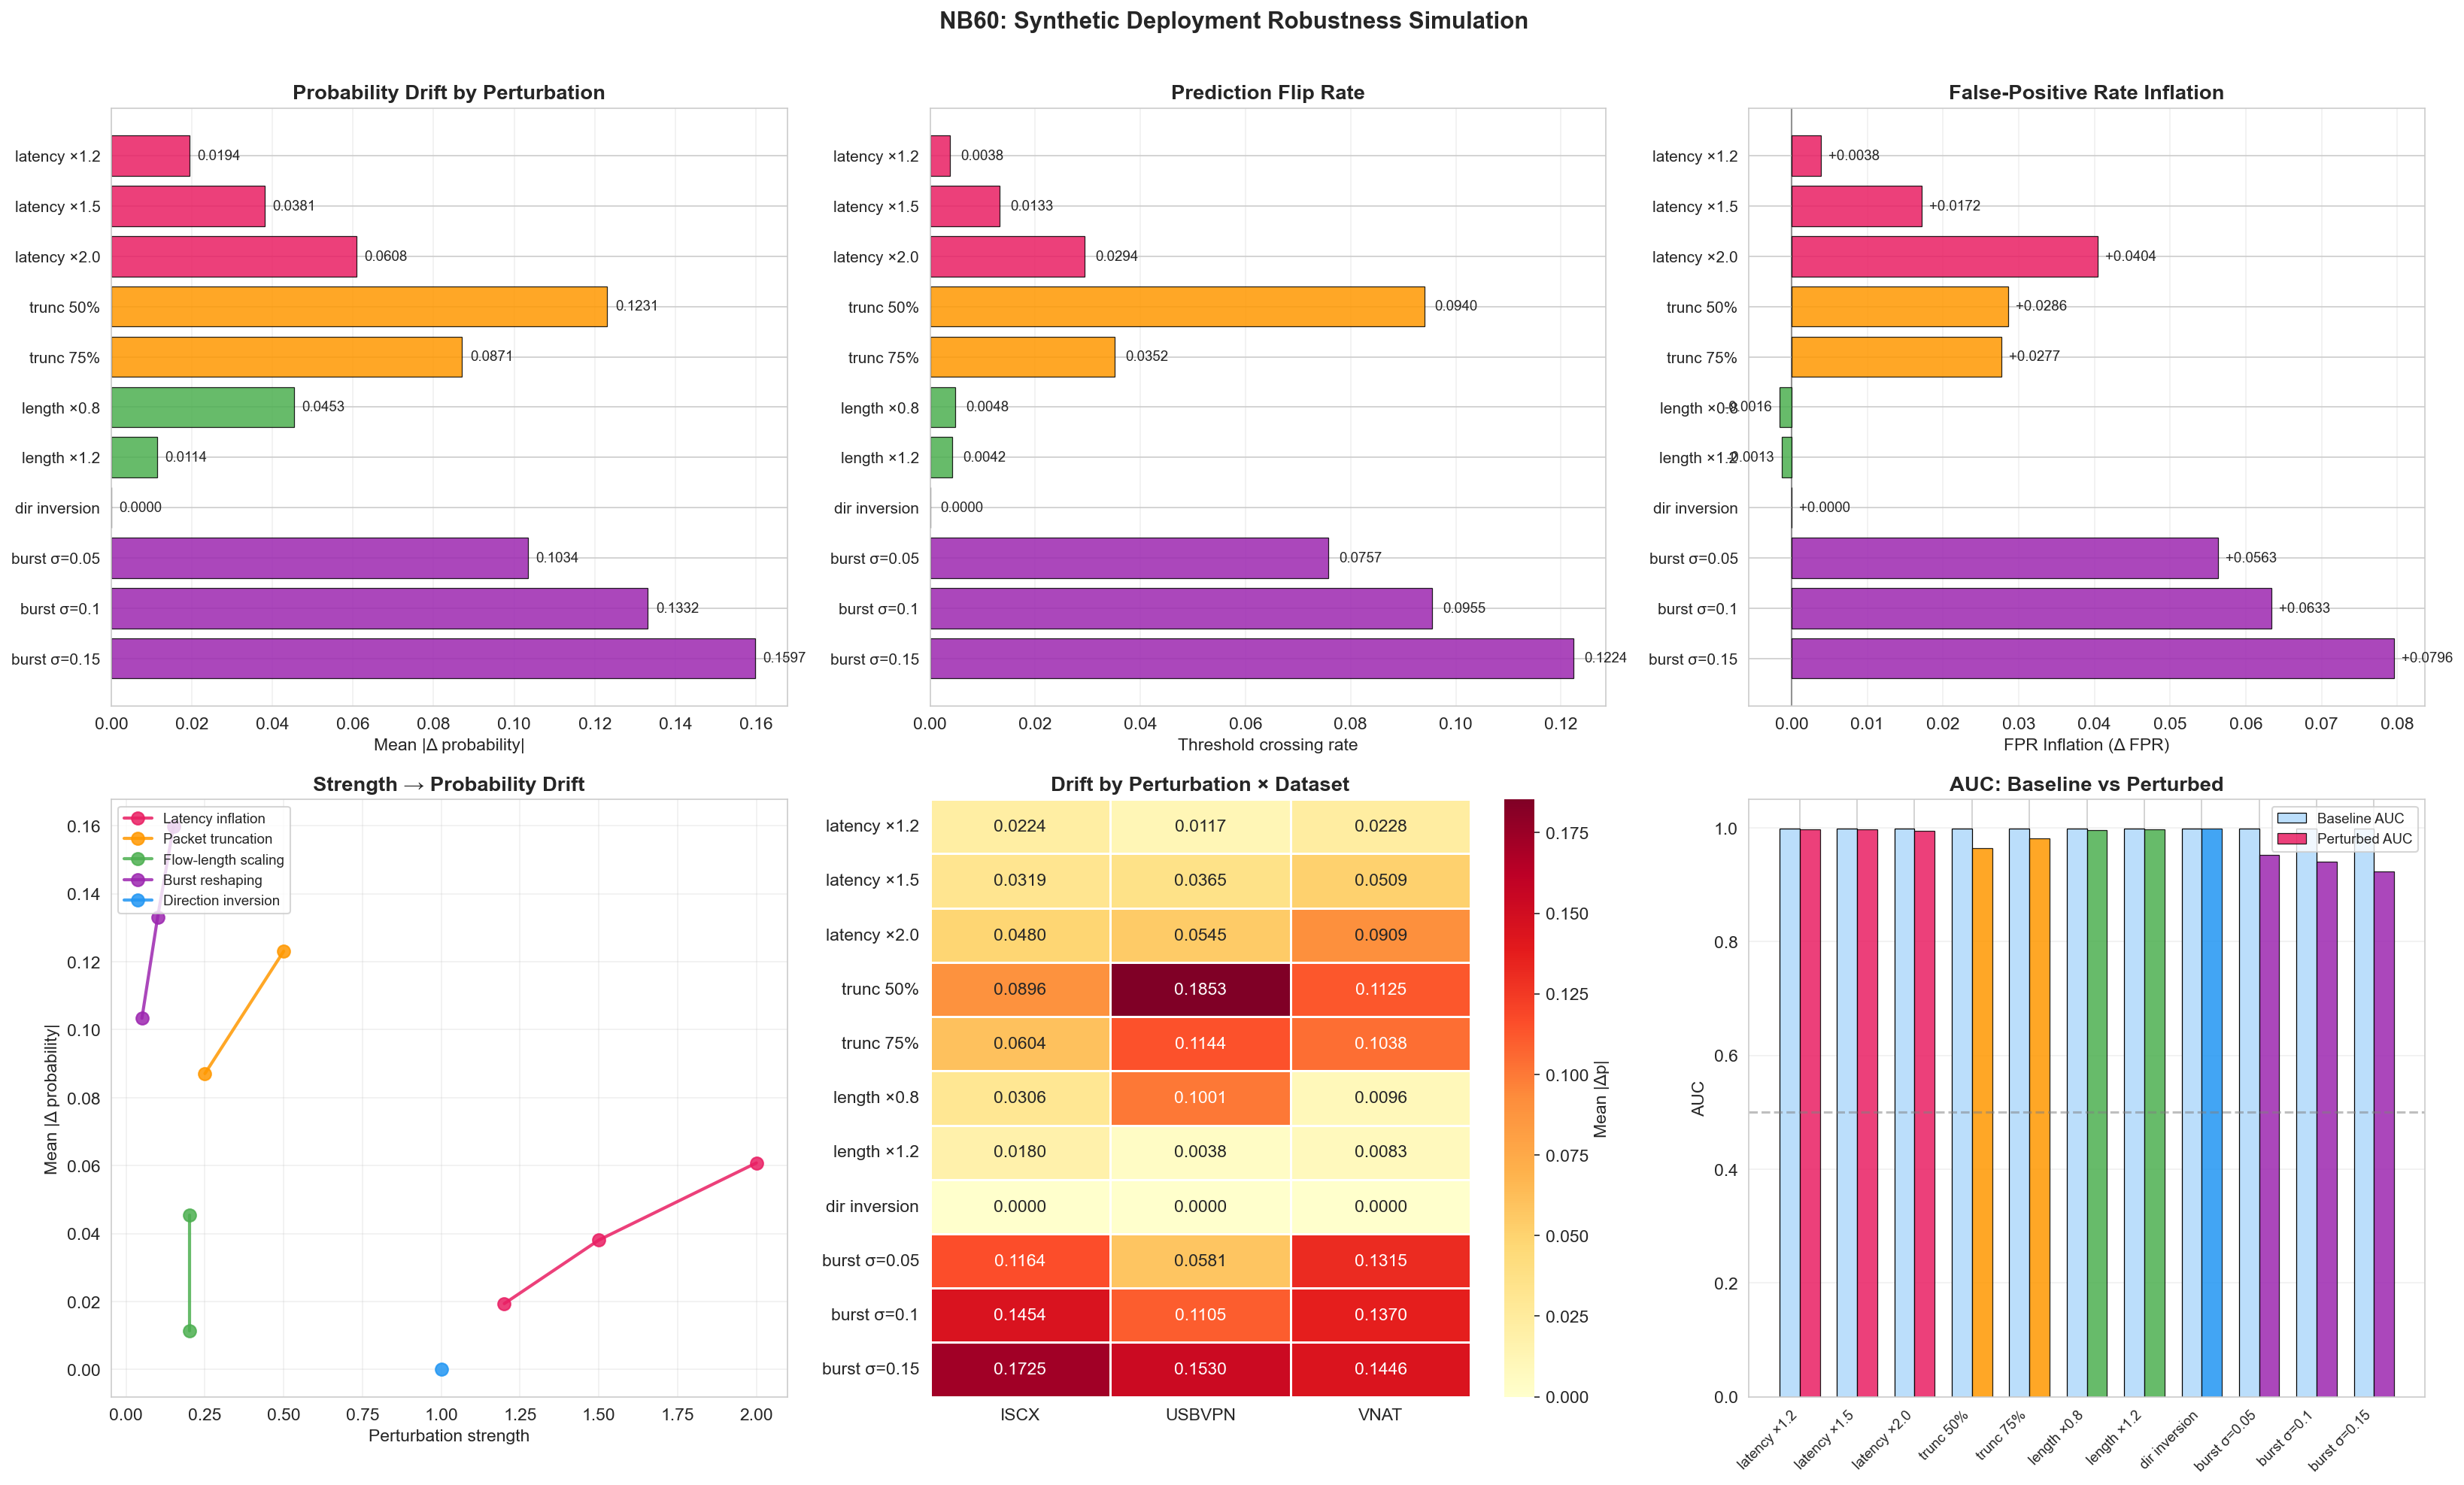


---
### 🖼 {_p.stem.replace("_", " ").title()}

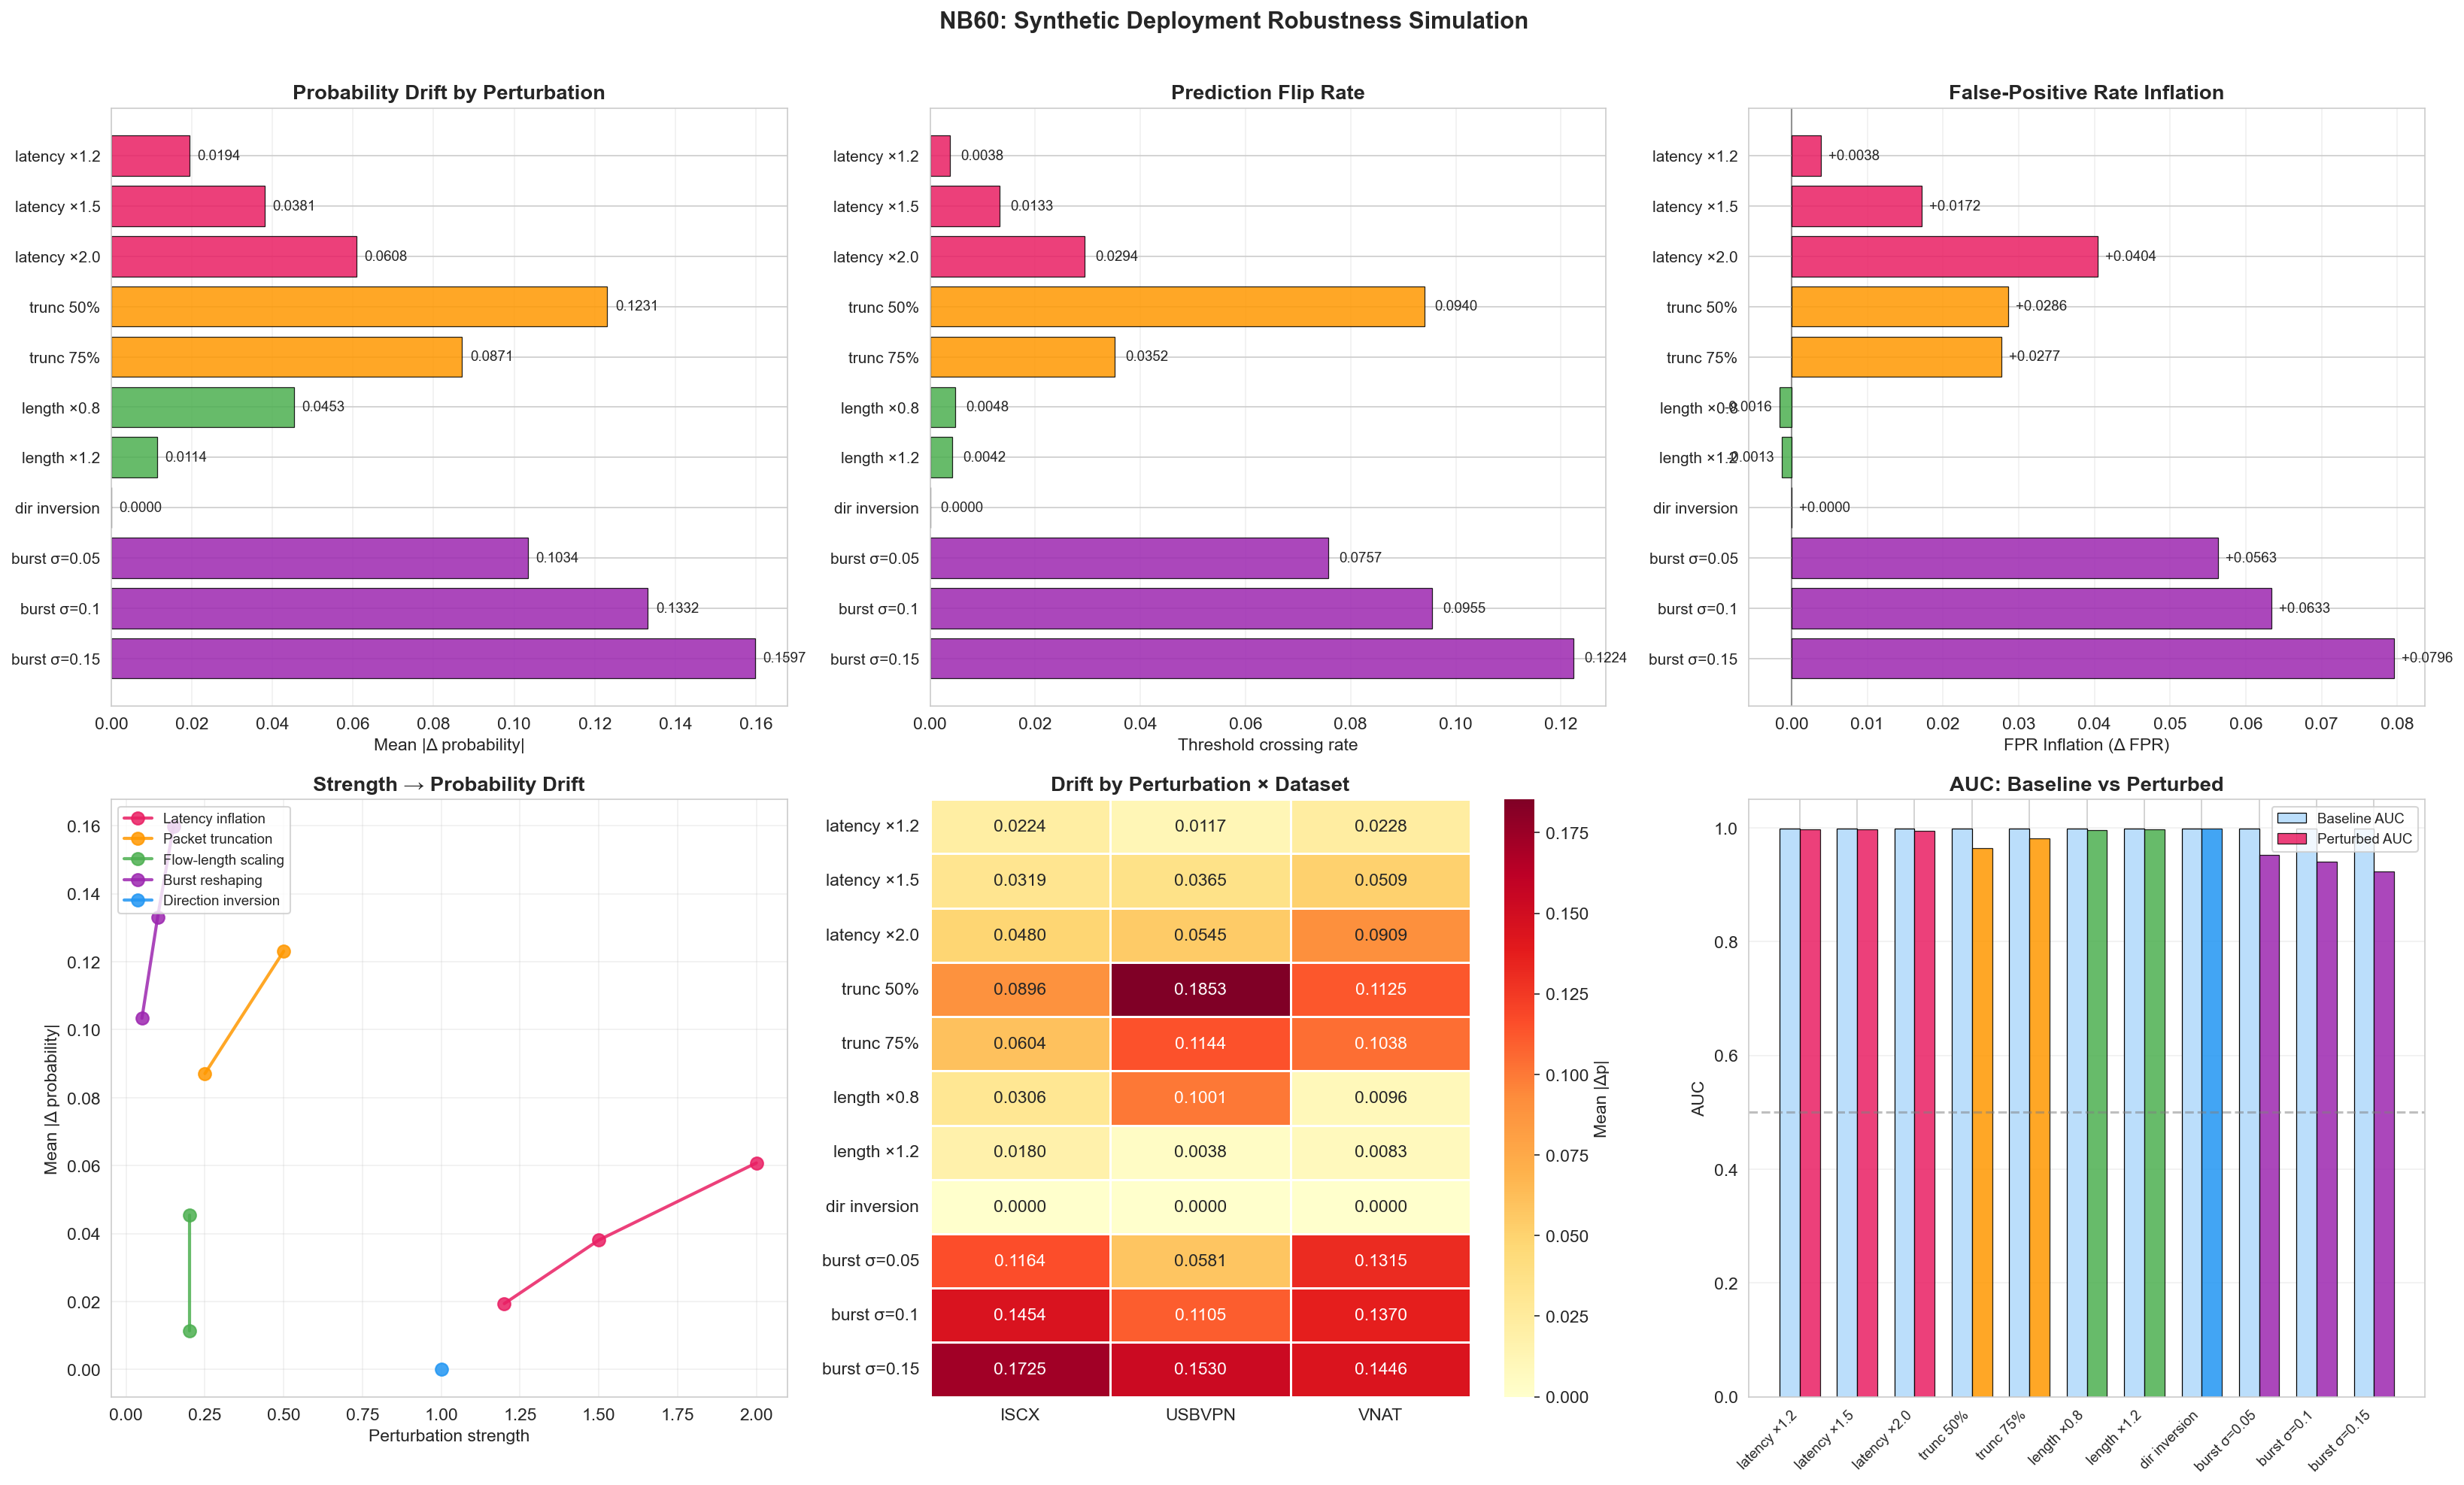


---
### 🖼 {_p.stem.replace("_", " ").title()}

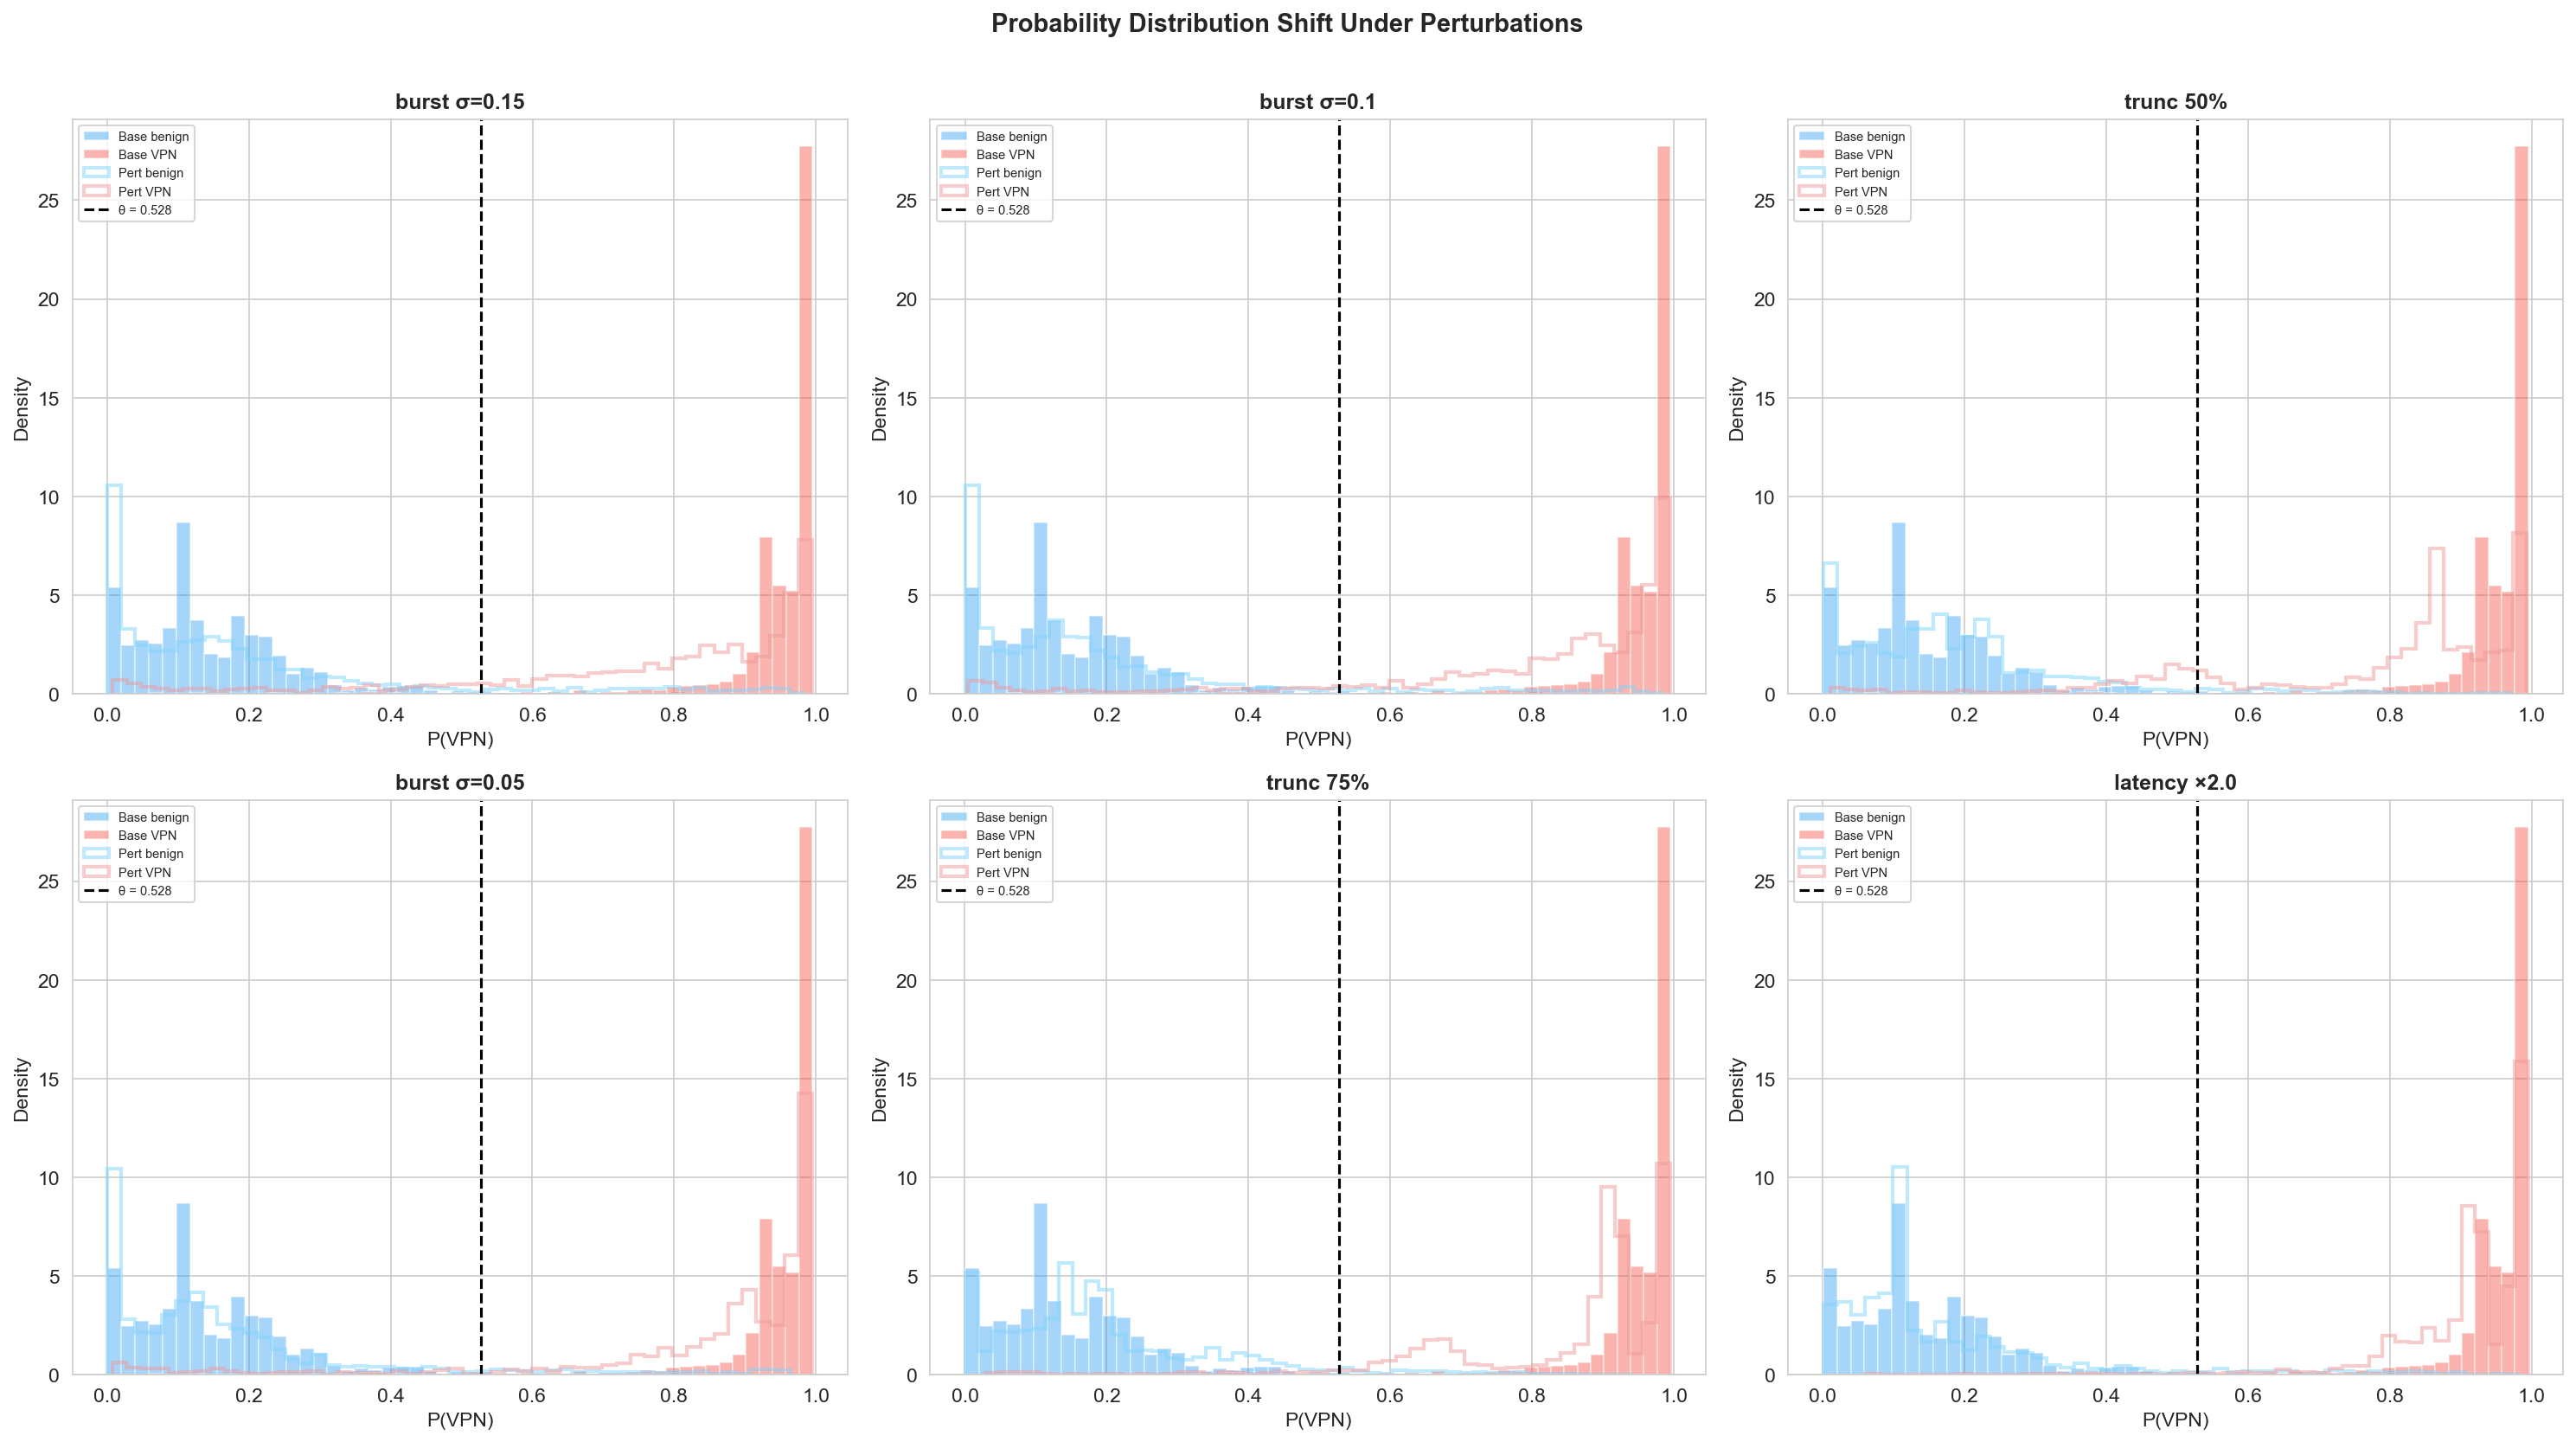


---
### 🖼 {_p.stem.replace("_", " ").title()}

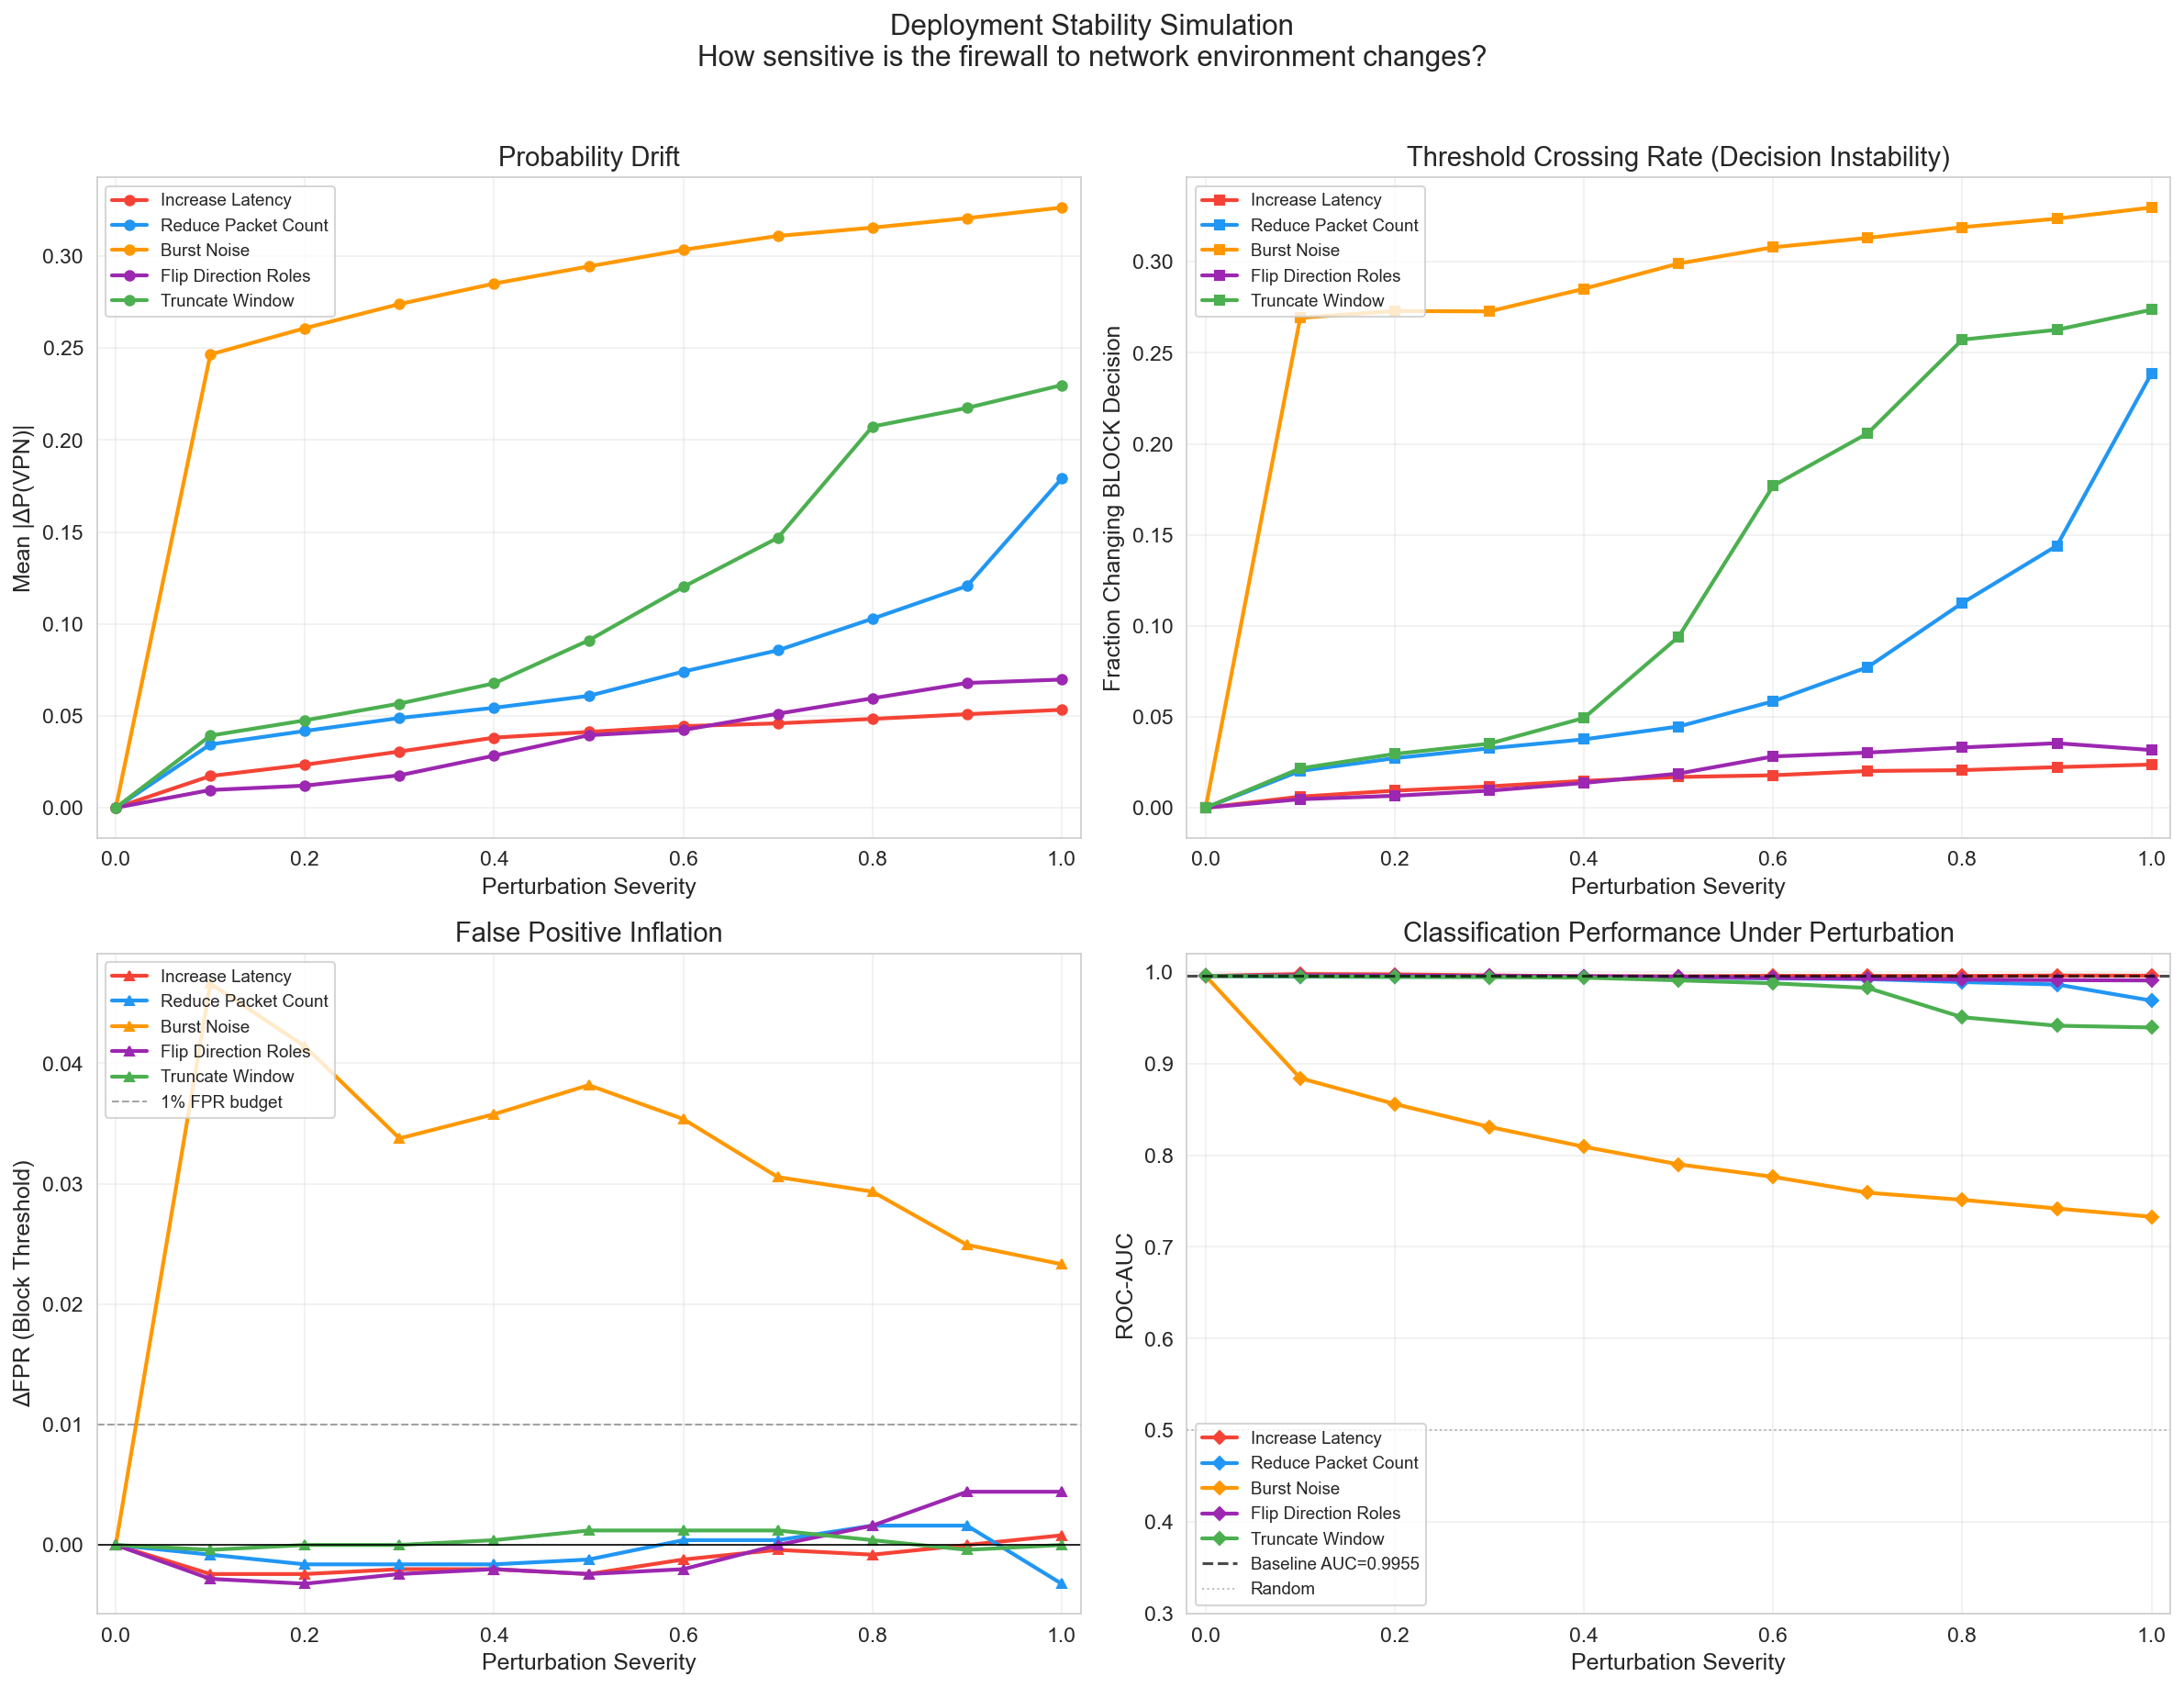


---
### 🖼 {_p.stem.replace("_", " ").title()}

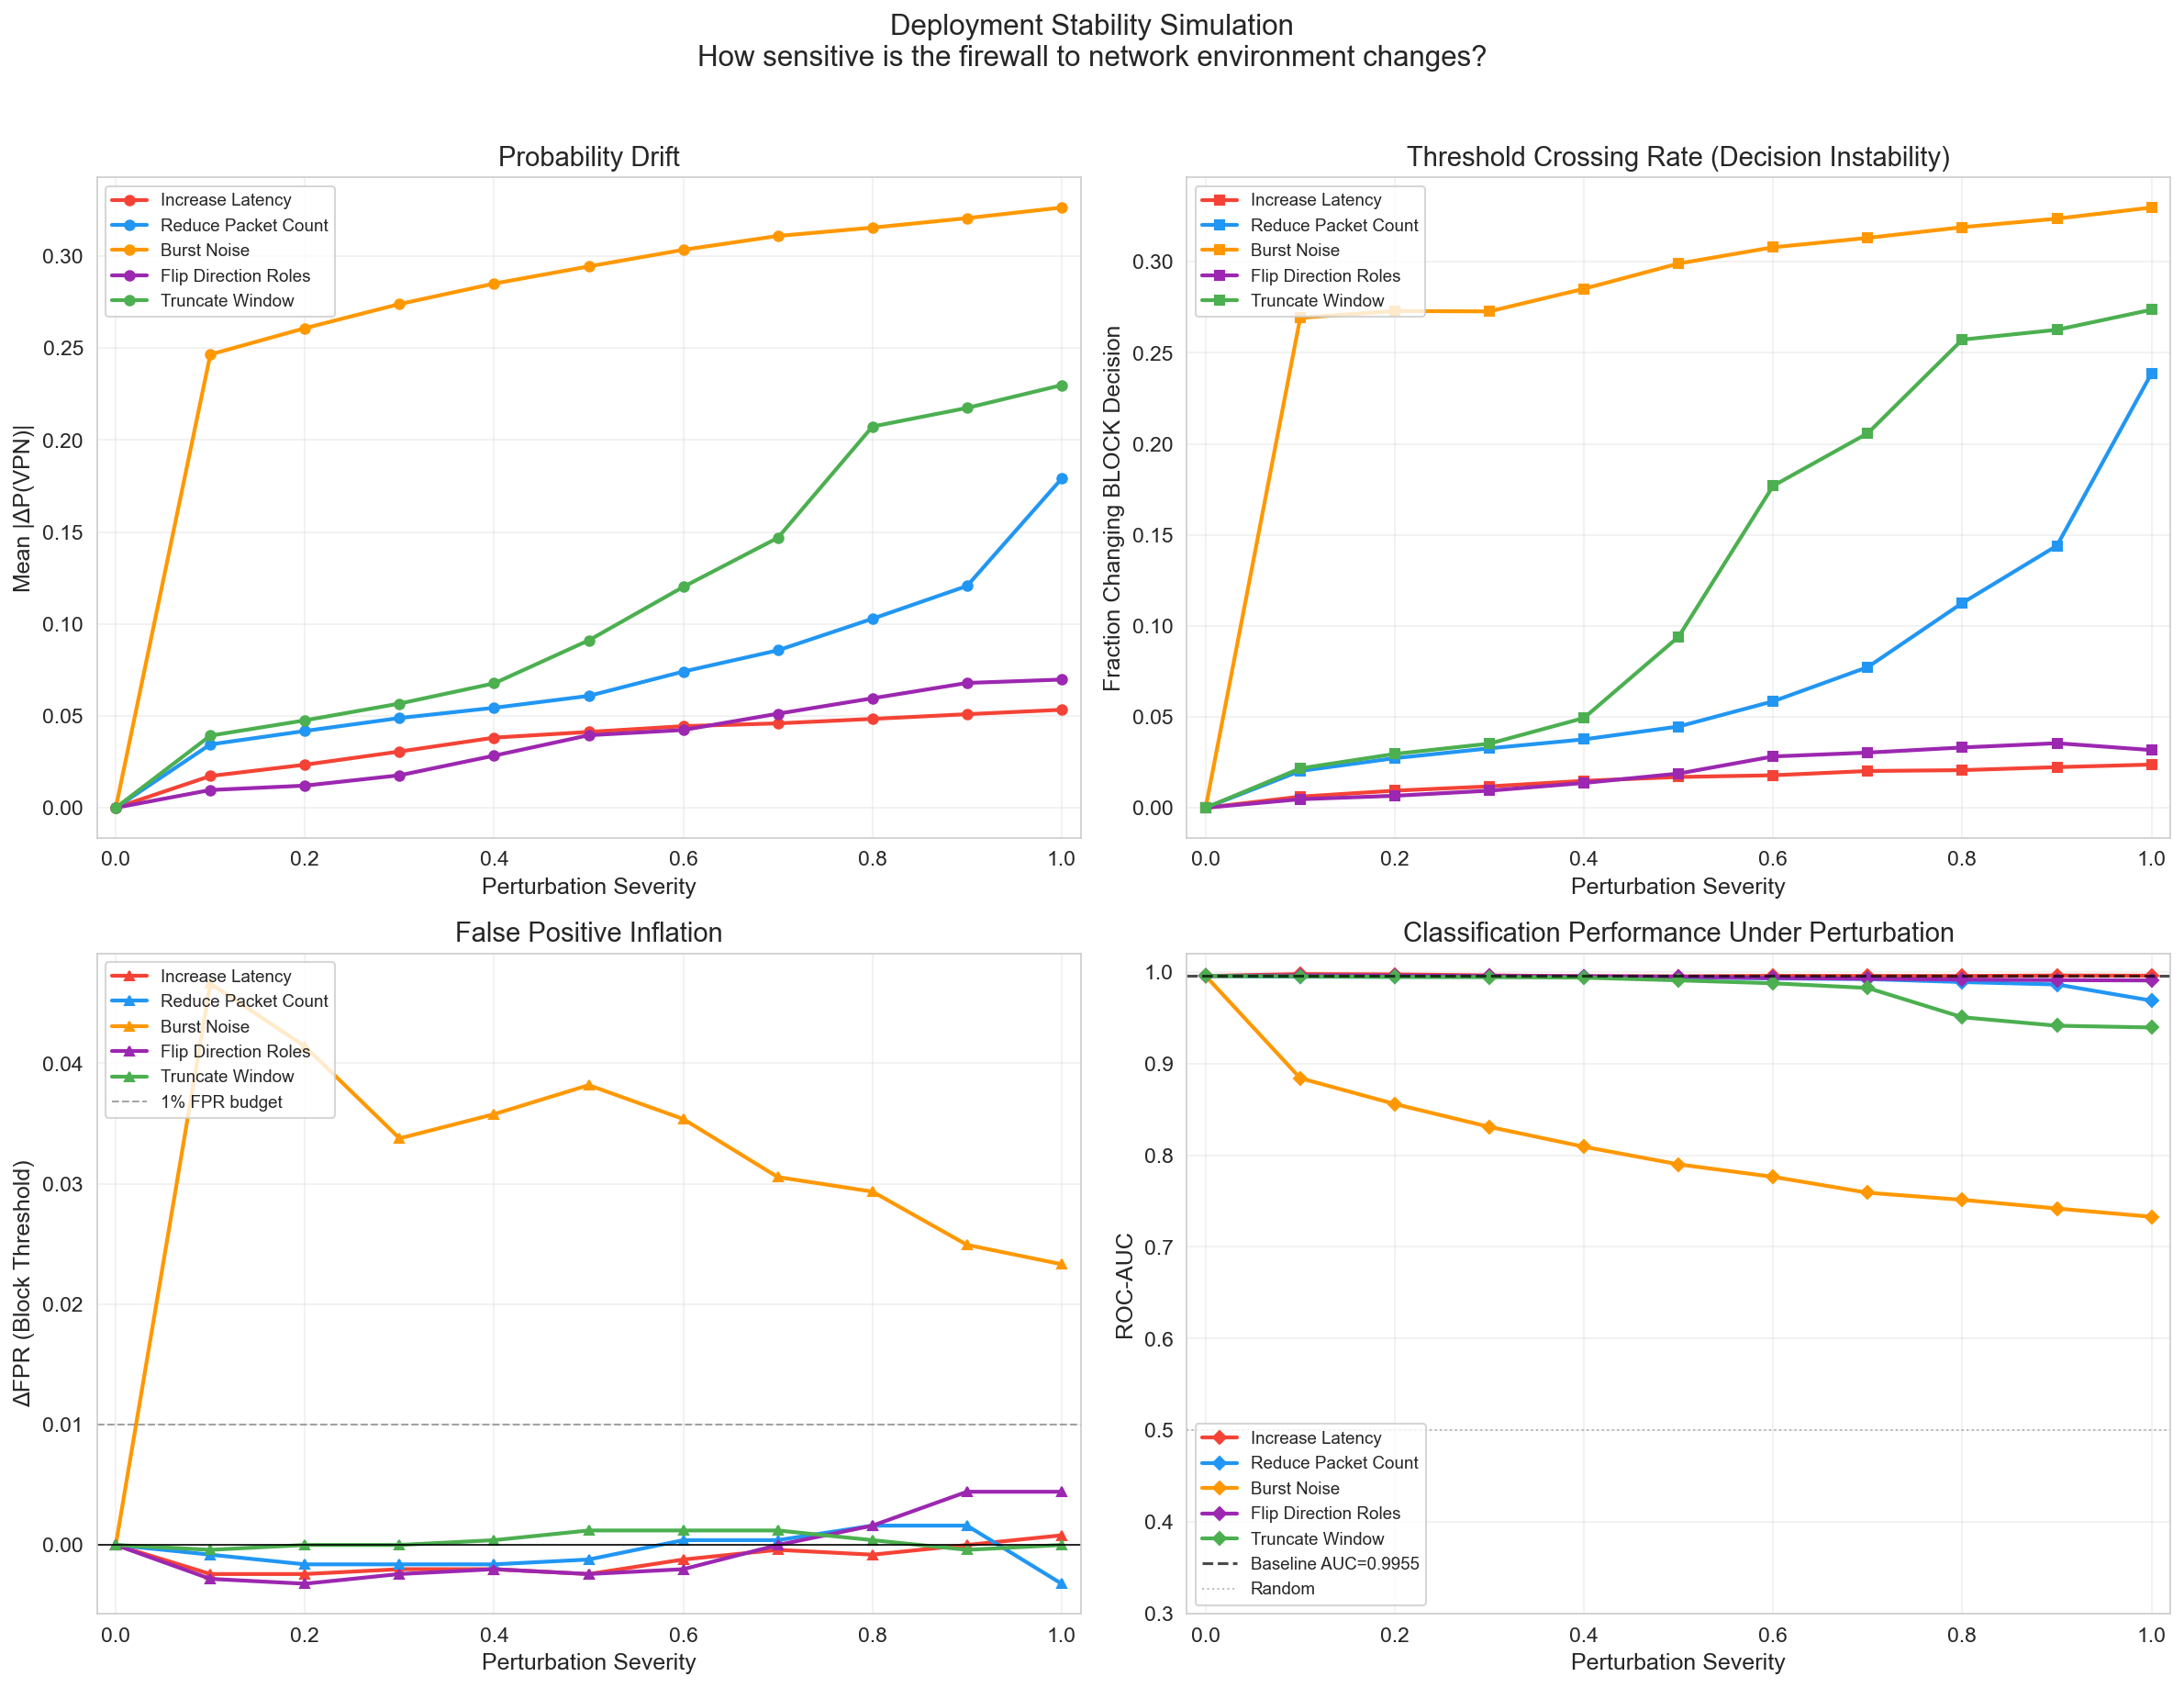


---
# 📋 Result Tables


### {_c.stem.replace("_", " ").title()}

,perturbation_type,perturbation_label,perturbation_strength,mean_prob_drift,median_prob_drift,max_prob_drift,threshold_crossing_rate,new_false_positives,lost_true_positives,base_fpr,...,usbvpn_mean_drift,usbvpn_crossing_rate,usbvpn_base_fp,usbvpn_pert_fp,usbvpn_n_benign,vnat_mean_drift,vnat_crossing_rate,vnat_base_fp,vnat_pert_fp,vnat_n_benign
0,none,baseline,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0.0178,...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,latency_inflation,latency ×1.2,1.2000,0.0194,0.0081,0.3258,0.0038,16,0,0.0178,...,0.0117,0.0000,12.0000,12.0000,36.0000,0.0228,0.0151,34.0000,46.0000,1200.0000
2,latency_inflation,latency ×1.5,1.5000,0.0381,0.0188,0.3688,0.0133,60,1,0.0178,...,0.0365,0.0000,12.0000,12.0000,36.0000,0.0509,0.0490,34.0000,89.0000,1200.0000
3,latency_inflation,latency ×2.0,2.0000,0.0608,0.0410,0.5040,0.0294,137,3,0.0178,...,0.0545,0.0000,12.0000,12.0000,36.0000,0.0909,0.1100,34.0000,162.0000,1200.0000
4,packet_truncation,trunc 50%,0.5000,0.1231,0.0758,0.9091,0.0940,111,355,0.0178,...,0.1853,0.1822,12.0000,6.0000,36.0000,0.1125,0.0671,34.0000,96.0000,1200.0000
5,packet_truncation,trunc 75%,0.2500,0.0871,0.0565,0.8588,0.0352,99,72,0.0178,...,0.1144,0.0186,12.0000,10.0000,36.0000,0.1038,0.0769,34.0000,121.0000,1200.0000
6,flow_length_scaling,length ×0.8,0.2000,0.0453,0.0097,0.4397,0.0048,2,16,0.0178,...,0.1001,0.0140,12.0000,6.0000,36.0000,0.0096,0.0015,34.0000,34.0000,1200.0000
7,flow_length_scaling,length ×1.2,0.2000,0.0114,0.0030,0.4580,0.0042,4,10,0.0178,...,0.0038,0.0027,12.0000,12.0000,36.0000,0.0083,0.0045,34.0000,32.0000,1200.0000
8,direction_inversion,dir inversion,1.0000,0.0000,0.0000,0.0000,0.0000,0,0,0.0178,...,0.0000,0.0000,12.0000,12.0000,36.0000,0.0000,0.0000,34.0000,34.0000,1200.0000
9,burst_reshaping,burst σ=0.05,0.0500,0.1034,0.0378,0.9361,0.0757,199,169,0.0178,...,0.0581,0.0126,12.0000,17.0000,36.0000,0.1315,0.0550,34.0000,68.0000,1200.0000


### {_c.stem.replace("_", " ").title()}

,perturbation,level,probability_drift,threshold_crossing_rate,fpr_original,fpr_perturbed,fpr_inflation,auc_original,auc_perturbed,auc_delta
0,increase_latency,0.0000,0.0000,0.0000,0.0052,0.0052,0.0000,0.9955,0.9955,0.0000
1,increase_latency,0.1000,0.0173,0.0061,0.0052,0.0028,-0.0024,0.9955,0.9975,0.0020
2,increase_latency,0.2000,0.0234,0.0094,0.0052,0.0028,-0.0024,0.9955,0.9971,0.0017
3,increase_latency,0.3000,0.0306,0.0117,0.0052,0.0032,-0.0020,0.9955,0.9961,0.0006
4,increase_latency,0.4000,0.0381,0.0148,0.0052,0.0032,-0.0020,0.9955,0.9952,-0.0003
5,increase_latency,0.5000,0.0412,0.0169,0.0052,0.0028,-0.0024,0.9955,0.9951,-0.0004
6,increase_latency,0.6000,0.0444,0.0179,0.0052,0.0040,-0.0012,0.9955,0.9956,0.0001
7,increase_latency,0.7000,0.0459,0.0202,0.0052,0.0048,-0.0004,0.9955,0.9955,0.0000
8,increase_latency,0.8000,0.0483,0.0207,0.0052,0.0044,-0.0008,0.9955,0.9955,0.0000
9,increase_latency,0.9000,0.0509,0.0223,0.0052,0.0052,0.0000,0.9955,0.9960,0.0005



---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB62",
  "title": "Dataset Scaling Law for Transfer",
  "datasets": [
    "iscx",
    "usbvpn",
    "vnat"
  ],
  "n_seeds": 3,
  "n_features": 21,
  "scaling_law": [
    {
      "datasets_used": 1,
      "transfer_auc_mean": 0.5113053907590712,
      "transfer_auc_std": 0.26913221057445286,
      "transfer_auc_min": 0.14165340330633205,
      "transfer_auc_max": 0.9006769966416175,
      "domain_auc": NaN,
      "n_evaluations": 18,
      "mean_train_flows": 20820
    },
    {
      "datasets_used": 2,
      "transfer_auc_mean": 0.5468154188256515,
      "transfer_auc_std": 0.16533461887471967,
      "transfer_auc_min": 0.3838519039157808,
      "transfer_auc_max": 0.7736556503795456,
      "domain_auc": 0.9998032553208515,
      "n_evaluations": 9,
      "mean_train_flows": 41640
    },
    {
      "datasets_used": 3,
      "transfer_auc_mean": 0.9956435308311173,
      "transfer_auc_std": 0.0021602940117162925,
      "transfer_auc_min": 0.9925446563729943,
      "transfer_auc_max": 0.9983727034120735,
      "domain_auc": 0.9997459737645702,
      "n_evaluations": 9,
      "mean_train_flows": 62461
    }
  ],
  "domain_classifier_aucs": {
    "iscx": NaN,
    "usbvpn": NaN,
    "vnat": NaN,
    "iscx+usbvpn": 0.9997,
    "iscx+vnat": 0.9998,
    "usbvpn+vnat": 0.9999,
    "iscx+usbvpn+vnat": 0.9997
  },
  "elapsed_seconds": 693.4
}
```


---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB60",
  "title": "Synthetic Deployment Robustness Simulation",
  "n_features": 21,
  "feature_set": [
    "total_packets",
    "total_bytes",
    "mean_pkt_len",
    "std_pkt_len",
    "median_pkt_len",
    "p25_pkt_len",
    "p75_pkt_len",
    "iat_mean",
    "iat_std",
    "iat_median",
    "flow_duration",
    "packet_rate",
    "byte_rate",
    "max_pkt_len",
    "min_pkt_len",
    "iat_cv",
    "iat_p25",
    "iat_p75",
    "iat_iqr",
    "pkt_len_cv",
    "pkt_len_iqr"
  ],
  "n_test_flows": 5203,
  "baseline_auc": 0.9981794911470054,
  "threshold": 0.5276475665891759,
  "models": [
    "xgb",
    "lgb",
    "cb"
  ],
  "perturbations": {
    "latency \u00d71.2": {
      "type": "latency_inflation",
      "strength": 1.2,
      "mean_prob_drift": 0.019396809399195768,
      "threshold_crossing_rate": 0.003843936190659235,
      "fp_inflation": 0.0038192234245703373,
      "auc_delta": -0.0001343491985836831
    },
    "latency \u00d71.5": {
      "type": "latency_inflation",
      "strength": 1.5,
      "mean_prob_drift": 0.0380998253041461,
      "threshold_crossing_rate": 0.013261579857774361,
      "fp_inflation": 0.01718650541056652,
      "auc_delta": -0.001102589974584789
    },
    "latency \u00d72.0": {
      "type": "latency_inflation",
      "strength": 2.0,
      "mean_prob_drift": 0.06079975526533983,
      "threshold_crossing_rate": 0.02940611185854315,
      "fp_inflation": 0.040420114576702734,
      "auc_delta": -0.003365833485441394
    },
    "trunc 50%": {
      "type": "packet_truncation",
      "strength": 0.5,
      "mean_prob_drift": 0.12309005022146684,
      "threshold_crossing_rate": 0.0939842398616183,
      "fp_inflation": 0.028644175684277528,
      "auc_delta": -0.03363100174159794
    },
    "trunc 75%": {
      "type": "packet_truncation",
      "strength": 0.25,
      "mean_prob_drift": 0.08707873407266772,
      "threshold_crossing_rate": 0.035172016144532,
      "fp_inflation": 0.027689369828134944,
      "auc_delta": -0.01604299297894174
    },
    "length \u00d70.8": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.04534924674036569,
      "threshold_crossing_rate": 0.0048049202383240435,
      "fp_inflation": -0.001591343093570976,
      "auc_delta": -0.0017094777337048894
    },
    "length \u00d71.2": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.0114067963444852,
      "threshold_crossing_rate": 0.004228329809725159,
      "fp_inflation": -0.0012730744748567814,
      "auc_delta": -0.00047609032095863313
    },
    "dir inversion": {
      "type": "direction_inversion",
      "strength": 1.0,
      "mean_prob_drift": 0.0,
      "threshold_crossing_rate": 0.0,
      "fp_inflation": 0.0,
      "auc_delta": 0.0
    },
    "burst \u03c3=0.05": {
      "type": "burst_reshaping",
      "strength": 0.05,
      "mean_prob_drift": 0.10335347673922901,
      "threshold_crossing_r
```


✅ NB60 gallery complete.


In [1]:
# ── Results Gallery: NB60 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "conference_eval"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

_prefix = 'deployment_robustness'
_pngs = [p for p in _pngs if _prefix in p.stem.lower() or 'deployme' in p.stem.lower()]
_csvs = [p for p in _csvs if _prefix in p.stem.lower() or 'deployme' in p.stem.lower()]

display(Markdown(f'# \U0001f4ca NB60 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB60 gallery complete.')
